# Predicción de salarios en el sector tecnológico

Cuaderno de trabajo. Va desde el archivo de la encuesta hasta las conclusiones,
sin saltarse pasos.

**Para ejecutarlo en tu equipo**

```
git clone https://github.com/debugsito/tech-salary-prediction.git
cd tech-salary-prediction
python -m venv .venv && .venv/bin/pip install -r requirements.txt
.venv/bin/jupyter lab notebooks/tesis_trabajo.ipynb
```

**Para ejecutarlo en Colab**: abre el enlace y pulsa «Ejecutar todo». La primera
celda se encarga del resto.

https://colab.research.google.com/github/debugsito/tech-salary-prediction/blob/main/notebooks/tesis_trabajo.ipynb

Descarga unos 400 MB de datos y tarda entre quince y cuarenta minutos según la
máquina. La semilla está fija en 42 en todas partes, así que dos ejecuciones dan
lo mismo.

In [1]:
import sys, subprocess
from pathlib import Path

if "google.colab" in sys.modules:
    if not Path("tech-salary-prediction").exists():
        subprocess.run(["git", "clone", "--depth", "1", "-q",
                        "https://github.com/debugsito/tech-salary-prediction.git"], check=True)
    RAIZ = Path("/content/tech-salary-prediction")
    for paquete in ("catboost", "shap"):
        try:
            __import__(paquete)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquete], check=True)
else:
    RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(RAIZ))
sys.path.insert(0, str(RAIZ / "scripts"))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

def figura(ruta):
    # Muestra la imagen, o avisa si faltaba el artefacto del que sale.
    if ruta is None:
        print("No se ha podido generar: falta el artefacto de origen.")
        return
    display(Image(ruta))

SEMILLA = 42

# Lo que produzca este cuaderno va a su propio directorio y no encima de
# results/ y figures/, que son los artefactos del proyecto. Si una celda falla a
# mitad, prefiero que no se lleve por delante nada que ya estaba bien.
SALIDA = RAIZ / "salida_cuaderno" / "results"
FIGURAS = RAIZ / "salida_cuaderno" / "figures"
SALIDA.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
print("Listo. Raíz:", RAIZ)

Listo. Raíz: /home/debugsito/Documents/local/tesis/tech-salary-prediction


## 1. Traer los datos y ver qué hay

La encuesta de Stack Overflow se publica en su propio repositorio, un CSV por
edición. Empiezo por la de 2023.

In [2]:
from src.data_loader_stackoverflow import descargar, COLUMNAS, TARGET

ruta = descargar("2023")
print(ruta, f"{ruta.stat().st_size / 1e6:.0f} MB")

# El archivo trae unas ochenta columnas y no necesito casi ninguna. Leo primero
# la cabecera para quedarme con las que sí.
cabecera = pd.read_csv(ruta, nrows=0)
print(f"\nColumnas en el archivo: {len(cabecera.columns)}")
usadas = [c for c in COLUMNAS if c in cabecera.columns]
print(f"Columnas que me quedo:   {len(usadas)}")
print(", ".join(usadas))

/home/debugsito/Documents/local/tesis/tech-salary-prediction/data/external/so_survey_2023.csv 159 MB

Columnas en el archivo: 84
Columnas que me quedo:   21
ResponseId, ConvertedCompYearly, Country, Employment, MainBranch, YearsCode, YearsCodePro, WorkExp, EdLevel, DevType, OrgSize, RemoteWork, Industry, ICorPM, Age, LanguageHaveWorkedWith, DatabaseHaveWorkedWith, PlatformHaveWorkedWith, WebframeHaveWorkedWith, AISelect, AIAcc


84 columnas en el archivo y me quedo con 21. La encuesta pregunta muchas cosas que
no tienen que ver con el salario (qué editor usas, qué sistema operativo) y
arrastrarlas solo haría la tabla más pesada.

In [3]:
bruto = pd.read_csv(ruta, usecols=usadas, low_memory=False)
print(f"{len(bruto):,} respuestas × {bruto.shape[1]} columnas\n")
bruto.head(3).T

89,184 respuestas × 21 columnas



,0,1,2
ResponseId,1,2,3
MainBranch,None of these,I am a developer by profession,I am a developer by profession
Age,18-24 years old,25-34 years old,45-54 years old
Employment,NaN,"Employed, full-time","Employed, full-time"
RemoteWork,NaN,Remote,"Hybrid (some remote, some in-person)"
EdLevel,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
YearsCode,NaN,18,27
YearsCodePro,NaN,9,23
DevType,NaN,"Senior Executive (C-Suite, VP, etc.)","Developer, back-end"
OrgSize,NaN,2 to 9 employees,"5,000 to 9,999 employees"


89,184 respuestas. Mirando las dos primeras ya se ve algo: la primera persona
tiene casi todo vacío porque en `MainBranch` marcó «None of these», así que
probablemente abandonó el cuestionario al principio.

También veo que las tecnologías vienen como una sola cadena con punto y coma
(`HTML/CSS;JavaScript;Python`). Eso habrá que separarlo.

## 2. La variable que quiero predecir

`ConvertedCompYearly` es la compensación anual que la propia encuesta convierte a
dólares. Antes de nada, a ver qué pinta tiene.

In [4]:
c = bruto[TARGET]
print(f"Declarada por {c.notna().sum():,} de {len(c):,} personas "
      f"({c.notna().mean()*100:.0f} %)\n")
print(c.describe().apply(lambda v: f"{v:,.0f}").to_string())
print(f"\nAsimetría: {c.skew():.2f}")

Declarada por 48,019 de 89,184 personas (54 %)

count        48,019
mean        103,110
std         681,419
min               1
25%          43,907
50%          74,963
75%         121,641
max      74,351,432

Asimetría: 94.74


Solo el 54 % declara compensación. Es mucha pérdida, pero sin salario no hay nada
que predecir.

Y la variable está sucia de verdad. El mínimo es **un dólar** y el máximo **74
millones**. La asimetría de 94.7 no es de una distribución con cola larga, es de
una distribución con basura dentro. La desviación típica (681,419) es casi siete
veces la media (103,110), que es otra señal de lo mismo.

In [5]:
# Miro los extremos para hacerme una idea de qué son esos valores.
extremos = bruto.loc[c.notna(), [TARGET, "Country", "Employment", "MainBranch"]]
print("Los cinco más altos:")
print(extremos.nlargest(5, TARGET).to_string(index=False))
print("\nLos cinco más bajos:")
print(extremos.nsmallest(5, TARGET).to_string(index=False))

Los cinco más altos:
 ConvertedCompYearly      Country                                           Employment                     MainBranch
          74351432.0       Canada Independent contractor, freelancer, or self-employed I am a developer by profession
          73607918.0 South Africa                                  I prefer not to say I am a developer by profession
          72714292.0    Australia Independent contractor, freelancer, or self-employed I am a developer by profession
          57513831.0     Thailand                                  Employed, full-time I am a developer by profession
          36573181.0         Mali                                  Employed, part-time I am a developer by profession

Los cinco más bajos:
 ConvertedCompYearly                      Country                                           Employment                     MainBranch
                 1.0                        India                                  Employed, full-time I am a devel

Confirmado, y ayuda ver de qué tipo son los errores.

Los cinco más altos van de 36 a 74 millones de dólares. No es que sean
ejecutivos bien pagados: son cifras imposibles. Y llama la atención que tres de
los cinco sean autónomos, que quizá declararon facturación en vez de salario, o
la cantidad en su moneda local sin convertir.

Los cinco más bajos son todos de un dólar exacto, en India, Uzbekistán, Vietnam,
Irán. Un dólar exacto no es un salario bajo, es alguien que puso «1» para pasar
de la pregunta.

Me quedo con una idea para después: los errores parecen ser de **escala**
(declarar el sueldo mensual, o poner mal el separador decimal), no valores
extremos legítimos.

## 3. Limpiar, un criterio cada vez

Voy a ir aplicando filtros de uno en uno y anotando cuánto se lleva cada uno. Al
final quiero poder decir exactamente por qué cada persona que queda está dentro.

In [6]:
from src.data_loader_stackoverflow import normalizar_ausentes

# La encuesta escribe la no respuesta como texto ("NA", "Prefer not to say"),
# que pandas no reconoce como nulo. Si no lo arreglo aquí, esas cadenas acabarán
# siendo categorías con nombre propio.
df = normalizar_ausentes(bruto.copy(), [c for c in usadas if c != TARGET])

registro = [("Respuestas totales de la edición", len(df))]
def anotar(criterio):
    descartados = registro[-1][1] - len(df)
    registro.append((criterio, len(df)))
    print(f"{criterio:58} quedan {len(df):>7,}   (−{descartados:,})")

print(f"{'Punto de partida':58} quedan {len(df):>7,}")

Punto de partida                                           quedan  89,184


In [7]:
# 1. Sin compensación declarada no hay nada que predecir.
df = df[df[TARGET].notna() & (df[TARGET] > 0)]
anotar("Reporta compensación anual")

Reporta compensación anual                                 quedan  48,019   (−41,165)


In [8]:
# 2. Solo asalariados. Los autónomos y quienes buscan empleo declaran ingresos
# que no son comparables con un salario.
df = df[df["Employment"].astype("string").str.startswith("Employed", na=False)]
anotar("Situación de empleo: asalariado")

Situación de empleo: asalariado                            quedan  43,776   (−4,243)


In [9]:
# 3. Solo quien se declara desarrollador de profesión. La encuesta la responde
# también mucha gente que programa por afición o estudia.
df = df[df["MainBranch"] == "I am a developer by profession"]
anotar("Desarrollador profesional")

Desarrollador profesional                                  quedan  40,410   (−3,366)


In [10]:
# 4. Países con pocas respuestas fuera. Con cinco o seis observaciones no hay
# forma de estimar nada del país, y además me hace falta su mediana en el paso
# siguiente.
frecuencia = df["Country"].value_counts()
print(f"Países antes: {len(frecuencia)}")
print(f"  con menos de 30 respuestas: {(frecuencia < 30).sum()}")
df = df[df["Country"].isin(frecuencia[frecuencia >= 30].index)]
anotar("País con al menos 30 observaciones")
print(f"Países después: {df['Country'].nunique()}")

Países antes: 165
  con menos de 30 respuestas: 87
País con al menos 30 observaciones                         quedan  39,682   (−728)
Países después: 78


El primer filtro se lleva 41,165 respuestas de golpe, el 46 % del total. Todos
los demás juntos no llegan ni de lejos.

Lo de los países me ha sorprendido: **87 de los 165 países tienen menos de 30
respuestas**, y entre los 87 solo suman 728 personas. Se van más de la mitad de
los países y menos del 2 % de la muestra.

### El filtro difícil: qué salario es creíble

Los extremos de antes no son salarios reales. Pero decidir dónde cortar no es
obvio, así que pruebo dos criterios y comparo.

In [11]:
from scipy.stats import skew

antes = df.copy()

# Opción A: recortar por percentiles globales, que es lo primero que se me ocurrió.
p1, p99 = antes[TARGET].quantile([0.01, 0.99])
a = antes[(antes[TARGET] >= p1) & (antes[TARGET] <= p99)]

# Opción B: relativo a la mediana del propio país.
mediana_pais = antes.groupby("Country")[TARGET].transform("median")
b = antes[(antes[TARGET] >= mediana_pais * 0.2) & (antes[TARGET] <= mediana_pais * 6)]

print(f"Percentiles globales: corte en ${p1:,.0f} y ${p99:,.0f}")
print(f"{'':22} {'quedan':>8} {'%':>7} {'asimetría':>10} {'tras log':>9}")
for nombre, sub in [("Sin filtrar", antes), ("A) p1-p99 global", a), ("B) [0.2, 6] × país", b)]:
    print(f"{nombre:22} {len(sub):>8,} {len(sub)/len(antes)*100:>6.1f}% "
          f"{skew(sub[TARGET]):>10.2f} {skew(np.log1p(sub[TARGET])):>9.2f}")

Percentiles globales: corte en $670 y $400,000
                         quedan       %  asimetría  tras log
Sin filtrar              39,682  100.0%     142.83     -2.54
A) p1-p99 global         38,917   98.1%       1.37     -1.43
B) [0.2, 6] × país       37,964   95.7%       2.56     -0.82


Aquí está lo interesante, y no es lo que esperaba.

La opción A conserva más gente (98.1 % contra 95.7 %) y deja la variable sin
transformar mucho más ordenada (asimetría 1.37 contra 2.56). Si me quedara con
esas dos columnas, elegiría A sin dudarlo.

Pero la columna que importa es la última, porque el modelo no se va a ajustar
sobre el salario sino sobre su logaritmo. Y ahí **A deja −1.43 y B deja −0.82**,
casi la mitad. B conserva salarios altos que el percentil 99 tiraba, y por eso su
asimetría sin transformar sube; en escala logarítmica, que es donde se trabaja,
el resultado es bastante mejor.

Me falta ver una cosa antes de decidir: a quién le quita las observaciones cada
uno.

In [12]:
# Cuál de los dos recortes cae sobre qué países, y por qué lado. Los recuentos
# en bruto engañan, porque los grupos son de tamaños muy distintos; miro el
# porcentaje de cada grupo que se lleva cada corte.
from src.data_loader_stackoverflow import derivar_region, cargar_referencia_paises
ref = cargar_referencia_paises()
con_renta = derivar_region(antes.copy(), ref)
med = con_renta.groupby("Country")[TARGET].transform("median")

print(f"{'':22} {'N':>7}   {'A: por abajo':>12} {'A: por arriba':>13}   "
      f"{'B: por abajo':>12} {'B: por arriba':>13}")
for g, sub in con_renta.groupby("income_group", observed=True):
    m, n = med.loc[sub.index], len(sub)
    print(f"{g:22} {n:>7,}   "
          f"{100*(sub[TARGET] < p1).sum()/n:>11.2f}% {100*(sub[TARGET] > p99).sum()/n:>12.2f}%   "
          f"{100*(sub[TARGET] < m*0.2).sum()/n:>11.2f}% {100*(sub[TARGET] > m*6).sum()/n:>12.2f}%")

                             N   A: por abajo A: por arriba   B: por abajo B: por arriba
High income             33,018          0.48%         1.06%          1.94%         0.28%
Lower middle income      2,407          4.20%         0.21%         11.09%         3.74%
Upper middle income      4,257          3.22%         0.28%         12.92%         1.83%


Esto es lo que quería mirar, y el resultado tiene matiz.

**El corte de A cae casi todo por abajo**, en el umbral de 670 dólares: se lleva
el 4.20 % de los países de renta media-baja y solo el 0.48 % de los de renta
alta, casi nueve veces más. Un sueldo de 600 dólares al año es raro en Alemania
pero no es imposible en un país de renta baja, así que ahí A está tirando
observaciones que pueden ser buenas.

**B quita más en total**, eso es cierto: 11-13 % en los grupos de menor renta
frente al 1.94 % en renta alta. Pero la desproporción es menor (unas seis veces,
no nueve) y sobre todo está mejor repartida entre las dos colas. En los países de
renta media-baja B se lleva un 3.74 % por arriba, que son justo esas cifras
infladas por factor 10 o 12 de las que hablaba antes.

No voy a fingir que B sea inocuo con los países pobres, porque no lo es. Lo que
sí hace es cortar donde están los errores en vez de cortar por una cantidad fija
que significa cosas distintas en cada sitio. Con eso y con la asimetría de −0.82,
me quedo con B.

In [13]:
df = b
anotar("Compensación dentro de [0.2, 6] veces la mediana del país")

Compensación dentro de [0.2, 6] veces la mediana del país  quedan  37,964   (−1,718)


### Último filtro: respuestas que se contradicen

In [14]:
from src.data_loader_stackoverflow import parsear_anios, TRAMO_EDAD_MAX

anios_total = parsear_anios(df["YearsCode"])
anios_pro = parsear_anios(df["YearsCodePro"])

# Quien dice llevar más años programando profesionalmente que programando en
# total ha rellenado mal el formulario.
mas_pro_que_total = (anios_pro > anios_total).fillna(False)

# Y quien, restando los años que dice llevar programando al extremo superior de
# su tramo de edad, habría empezado antes de los ocho años.
edad_max = df["Age"].map(TRAMO_EDAD_MAX)
empezo_demasiado_pronto = ((edad_max - anios_total) < 8).fillna(False)

print(f"Más años profesionales que totales: {mas_pro_que_total.sum():,}")
print(f"Habría empezado antes de los 8 años: {empezo_demasiado_pronto.sum():,}")
print(f"Alguna de las dos:                  {(mas_pro_que_total | empezo_demasiado_pronto).sum():,}")

df = df[~(mas_pro_que_total | empezo_demasiado_pronto)].reset_index(drop=True)
anotar("Coherencia entre años declarados y tramo de edad")

Más años profesionales que totales: 287
Habría empezado antes de los 8 años: 56
Alguna de las dos:                  342
Coherencia entre años declarados y tramo de edad           quedan  37,622   (−342)


342 respuestas se contradicen a sí mismas. La mayoría (287) dicen llevar más años
programando profesionalmente que programando en total, que es imposible.

Son pocas y da algo de pereza el filtro, pero son errores de captura, no valores
raros: no hay forma de interpretarlas literalmente, y si las dejo el modelo
aprende de ellas.

In [15]:
tabla_filtros = pd.DataFrame(registro, columns=["Criterio", "N resultante"])
tabla_filtros["Descartados"] = tabla_filtros["N resultante"].diff().fillna(0).abs().astype(int)
tabla_filtros.loc[0, "Descartados"] = 0
print(tabla_filtros.to_string(index=False))
print(f"\nMe quedo con {len(df):,} de {registro[0][1]:,} "
      f"({len(df)/registro[0][1]*100:.1f} %) en {df['Country'].nunique()} países.")

                                                 Criterio  N resultante  Descartados
                         Respuestas totales de la edición         89184            0
                               Reporta compensación anual         48019        41165
                          Situación de empleo: asalariado         43776         4243
                                Desarrollador profesional         40410         3366
                       País con al menos 30 observaciones         39682          728
Compensación dentro de [0.2, 6] veces la mediana del país         37964         1718
         Coherencia entre años declarados y tramo de edad         37622          342

Me quedo con 37,622 de 89,184 (42.2 %) en 78 países.


## 4. Terminar de preparar la tabla

Faltan las variables derivadas: el logaritmo del salario, los años como número,
la región y el nivel de renta del país, y las tecnologías, que vienen como listas
separadas por punto y coma dentro de una sola celda.

In [16]:
from src.data_loader_stackoverflow import expandir_multivalor, CATEGORIA_AUSENTE

df = derivar_region(df, ref)
for col in ("YearsCode", "YearsCodePro", "WorkExp"):
    df[f"{col}_num"] = parsear_anios(df[col])
df["salary_log"] = np.log1p(df[TARGET])

# Las categóricas ausentes reciben una categoría propia en vez de imputarse: no
# declarar el sector es un dato, no un hueco que haya que rellenar.
for col in ("EdLevel", "DevType", "OrgSize", "RemoteWork", "Industry", "ICorPM", "Age"):
    df[col] = df[col].fillna(CATEGORIA_AUSENTE)

print("Antes de expandir, una celda de lenguajes se ve así:")
print(" ", df["LanguageHaveWorkedWith"].dropna().iloc[0][:110])

antes_cols = df.shape[1]
for col in ("LanguageHaveWorkedWith", "DatabaseHaveWorkedWith", "PlatformHaveWorkedWith"):
    df, nuevas = expandir_multivalor(df, col)
    print(f"{col:28} → {len(nuevas)} columnas binarias")
print(f"\nLa tabla pasa de {antes_cols} a {df.shape[1]} columnas.")

Antes de expandir, una celda de lenguajes se ve así:
  HTML/CSS;JavaScript;Python


LanguageHaveWorkedWith       → 49 columnas binarias


DatabaseHaveWorkedWith       → 32 columnas binarias


PlatformHaveWorkedWith       → 25 columnas binarias

La tabla pasa de 27 a 133 columnas.


In [17]:
# Comprobación: ¿mi versión paso a paso coincide con la del módulo?
from src.data_loader_stackoverflow import cargar_encuesta
oficial, _ = cargar_encuesta(anio="2023")
print(f"A mano:      {len(df):,} × {df.shape[1]}")
print(f"Del módulo:  {len(oficial):,} × {oficial.shape[1]}")
print("Coinciden." if len(df) == len(oficial) and df.shape[1] == oficial.shape[1]
      else "NO coinciden: hay un paso que se me ha escapado.")

A mano:      37,622 × 133
Del módulo:  37,622 × 133
Coinciden.


Coincide, 37,622 filas y 133 columnas por los dos caminos. Bien, porque significa
que no me he saltado ningún paso al hacerlo a mano.

De 89,184 me quedo con 37,622, el 42.2 %. Es menos de la mitad y conviene decirlo
claro: esto **no** es una muestra representativa de los desarrolladores del
mundo. Es quien responde la encuesta de Stack Overflow, declara su sueldo,
trabaja por cuenta ajena y vive en uno de los 78 países con suficientes
respuestas.

## 5. Mirar la muestra ya limpia

Mediana  $    78,175
Media    $    96,319
Asimetría       2.56   ·   tras log1p  -0.82


  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/dist_compensacion.png


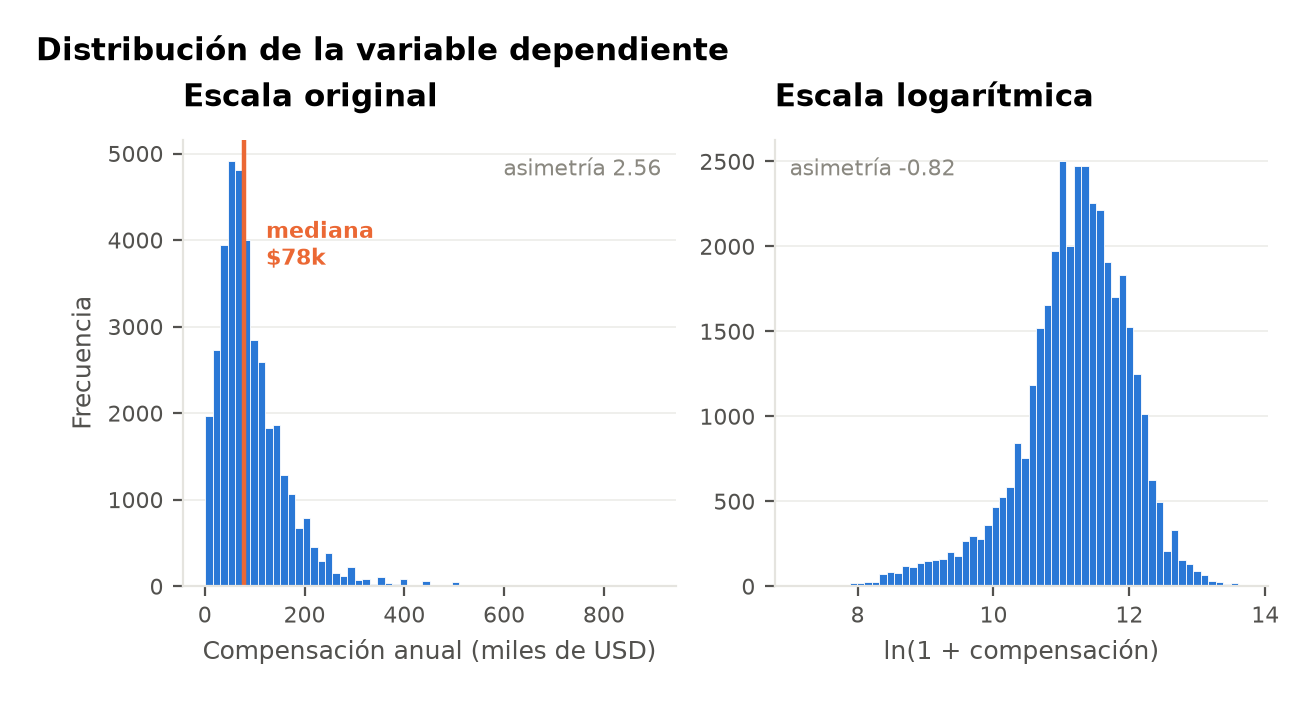

In [18]:
from scripts.generate_figures import estilo, fig_distribucion, fig_composicion
estilo()

print(f"Mediana  ${df[TARGET].median():>10,.0f}")
print(f"Media    ${df[TARGET].mean():>10,.0f}")
print(f"Asimetría {df[TARGET].skew():>10.2f}   ·   tras log1p {df['salary_log'].skew():>6.2f}")

figura(fig_distribucion(df, FIGURAS))

La mediana está en 78,175 dólares y la media en 96,319: la media va casi veinte
mil por encima, que es lo que pasa cuando la cola de la derecha pesa.

En el gráfico de la izquierda se ve el amontonamiento a la izquierda y la cola
larga. En el de la derecha, tras el logaritmo, la forma es mucho más manejable,
aunque no es una campana: hay un bulto a la izquierda que es lo que deja la
asimetría en −0.82.

A partir de aquí trabajo sobre el logaritmo.

                         N  Mediana      P25       P75  % muestra
income_group                                                     
High income          32027  86743.0  58899.0  135000.0       85.0
Lower middle income   2017  16964.0   8361.0   30292.0        5.0
Upper middle income   3578  33758.0  18038.0   57590.0       10.0
  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/composicion_renta.png


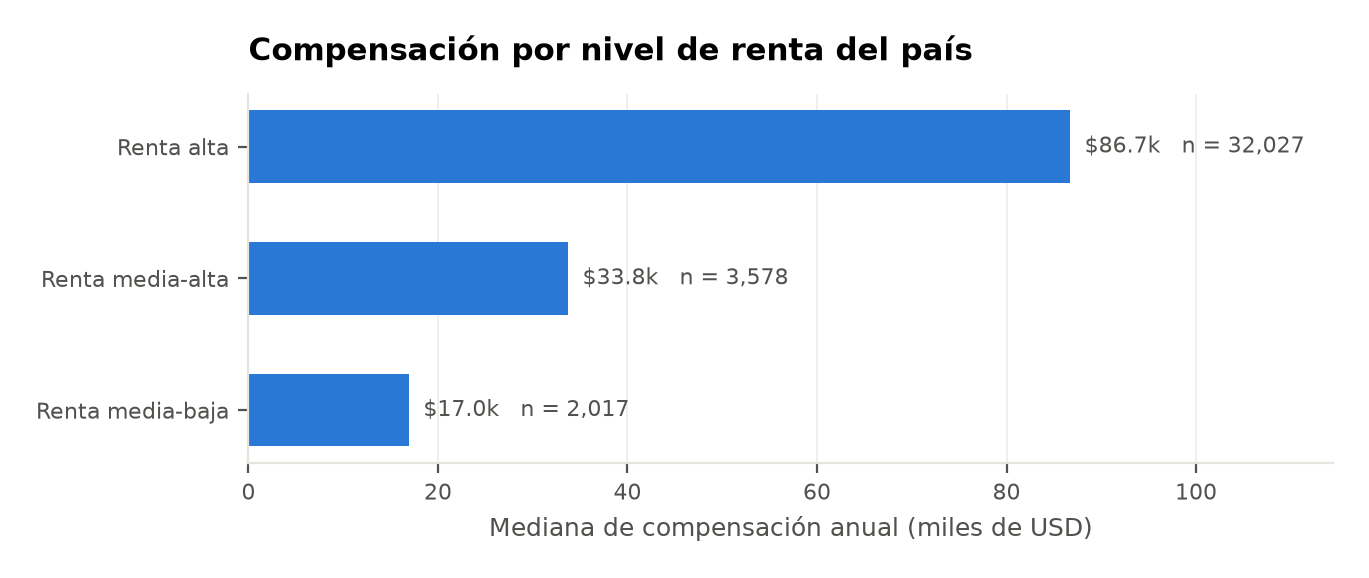

In [19]:
comp = (df.groupby("income_group", observed=True)[TARGET]
          .agg(N="size", Mediana="median",
               P25=lambda s: s.quantile(.25), P75=lambda s: s.quantile(.75)))
comp["% muestra"] = (comp["N"] / len(df) * 100).round(1)
print(comp.round(0).to_string())

figura(fig_composicion(df, FIGURAS))

El 85 % de la muestra son países de renta alta, y la mediana de ese grupo (86,743)
es **cinco veces** la de renta media-baja (16,964).

Dos cosas que me apunto. Una, cualquier media global va a estar dominada por los
países ricos. Y dos, si reparto entrenamiento y prueba al azar, con solo un 5 %
de renta media-baja puede tocarme un reparto desigual; mejor estratificar.

## 6. Los predictores, y el problema del país

Separo lo que entra al modelo de lo que solo sirve para auditarlo después.

In [20]:
from src.feature_pipeline_so import preparar_xy, CAT_ALTA, CAT_BAJA, NUMERICAS

X, y, A = preparar_xy(df)
print(f"X: {X.shape[0]:,} filas × {X.shape[1]} columnas")
print(f"y: logaritmo del salario")
print(f"A: {list(A.columns)}  ← fuera del modelo, para auditar después\n")

# Cuento las categorías realmente declaradas: "No declarado" es una etiqueta que
# he puesto yo y contarla como una más inflaría la cardinalidad.
print("Cardinalidad de las categóricas:")
for col in CAT_ALTA + CAT_BAJA:
    if col in X.columns:
        declaradas = X[col][X[col] != CATEGORIA_AUSENTE]
        print(f"  {col:14} {declaradas.nunique():>4} categorías   "
              f"cobertura {len(declaradas)/len(X)*100:>5.1f} %")

X: 37,622 filas × 119 columnas
y: logaritmo del salario
A: ['income_group', 'wb_region', 'Country', 'Age', 'EdLevel', 'OrgSize']  ← fuera del modelo, para auditar después

Cardinalidad de las categóricas:
  Country          78 categorías   cobertura 100.0 %
  DevType          33 categorías   cobertura  99.9 %
  EdLevel           8 categorías   cobertura 100.0 %
  OrgSize          10 categorías   cobertura  99.9 %
  RemoteWork        3 categorías   cobertura 100.0 %
  Industry         12 categorías   cobertura  61.6 %
  ICorPM            2 categorías   cobertura  72.0 %
  Age               7 categorías   cobertura 100.0 %
  income_group      3 categorías   cobertura 100.0 %


119 columnas entran al modelo. `Country` tiene 78 categorías y `DevType` 33: son
las dos que van a dar problemas, porque si las convierto en variables binarias
añaden más de cien columnas ellas solas.

`Industry` solo la declara el 61.6 % e `ICorPM` el 72 %. No las imputo: les pongo
una categoría «No declarado» y que el modelo decida si le dice algo. Rellenar con
la moda sería inventarme el dato.

El género no está: la edición 2023 ya no lo publica. Habrá que ir a 2022 para eso.

In [21]:
from src.feature_pipeline_so import construir_preprocesador, nombres_de_variables
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru, A_ent, A_pru = train_test_split(
    X, y, A, test_size=0.20, random_state=SEMILLA, stratify=df["income_group"])

# Estratifico por nivel de renta y no al azar: con el 85 % de la muestra en un
# solo grupo, una partición aleatoria puede dejar los grupos pequeños muy
# desigualmente repartidos.
print(f"Entrenamiento {len(X_ent):,}   ·   prueba {len(X_pru):,}\n")
print("Reparto por nivel de renta (%):")
print(pd.DataFrame({
    "entrenamiento": df.loc[X_ent.index, "income_group"].value_counts(normalize=True) * 100,
    "prueba": df.loc[X_pru.index, "income_group"].value_counts(normalize=True) * 100,
}).round(1).to_string())

for cod in ("target", "onehot"):
    pre = construir_preprocesador(df, cod).fit(X_ent, y_ent)
    print(f"\nCodificación «{cod}»: {X.shape[1]} columnas de entrada "
          f"→ {len(nombres_de_variables(pre))} tras codificar")

Entrenamiento 30,097   ·   prueba 7,525

Reparto por nivel de renta (%):
                     entrenamiento  prueba
income_group                              
High income                   85.1    85.1
Upper middle income            9.5     9.5
Lower middle income            5.4     5.4



Codificación «target»: 119 columnas de entrada → 162 tras codificar



Codificación «onehot»: 119 columnas de entrada → 261 tras codificar


El reparto por nivel de renta queda idéntico entre entrenamiento y prueba, que es
justo lo que buscaba con la estratificación.

Y aquí se ve el problema de `Country` y `DevType` en números: las mismas 119
columnas de entrada dan **162** con codificación por objetivo y **261** con
codificación disyuntiva. Cien columnas de diferencia, casi todas categorías de
país. Voy a probar las dos y comparar, porque no tengo claro cuál conviene.

## 7. ¿Contra qué comparo?

Antes de entrenar nada conviene saber cuánto vale no hacer nada. Si el modelo no
le gana a responder siempre la media, no sirve.

In [22]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from src.metrics import compute_metrics
from src.model_registry import build_models

modelos = {
    "Baseline_media": DummyRegressor(strategy="mean"),
    "Baseline_mediana": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=1.0),
    **build_models(),
}
print("Voy a evaluar:", ", ".join(modelos))

for nombre in ("Baseline_media", "Baseline_mediana"):
    t = Pipeline([("preprocesador", construir_preprocesador(df, "target")),
                  ("modelo", modelos[nombre])]).fit(X_ent, y_ent)
    m = compute_metrics(y_pru, t.predict(X_pru))
    print(f"\n{nombre}:  R² = {m['R2']:.4f}   MAE = ${m['MAE_USD']:,.0f}")

Voy a evaluar: Baseline_media, Baseline_mediana, Ridge, HistGradientBoosting, XGBoost, LightGBM, CatBoost



Baseline_media:  R² = -0.0002   MAE = $49,826



Baseline_mediana:  R² = -0.0057   MAE = $49,520


R² de −0.0002 y −0.0057. Negativos, como debe ser: responder siempre la media no
explica nada, y responder la mediana es incluso un poco peor porque la
distribución no es simétrica.

El dato que me quedo es el MAE: **49,826 dólares** de error medio sin usar
ninguna variable. Ese es el listón.

## 8. Validación cruzada

Una sola partición no me dice si la diferencia entre dos modelos es real o es la
suerte del reparto. Uso validación cruzada repetida, sobre las mismas
particiones para todos, para poder compararlos de dos en dos.

In [23]:
import time
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold

N_PARTICIONES, N_REPETICIONES = 5, 4
particionador = RepeatedStratifiedKFold(n_splits=N_PARTICIONES,
                                        n_repeats=N_REPETICIONES,
                                        random_state=SEMILLA)
estratos = df.loc[X_ent.index, "income_group"].astype(str)

filas, t0 = [], time.perf_counter()
for i, (tr, va) in enumerate(particionador.split(X_ent, estratos)):
    for codificacion in ("target", "onehot"):
        for nombre, modelo in modelos.items():
            # El preprocesador se reajusta dentro de cada partición: la
            # codificación por objetivo usa la y, y ajustarla fuera dejaría
            # entrar información del conjunto de validación.
            t = Pipeline([("preprocesador", construir_preprocesador(df, codificacion)),
                          ("modelo", clone(modelo))])
            t.fit(X_ent.iloc[tr], y_ent[tr])
            m = compute_metrics(y_ent[va], t.predict(X_ent.iloc[va]))
            m.update({"modelo": nombre, "codificacion": codificacion, "particion": i})
            filas.append(m)
    if (i + 1) % N_PARTICIONES == 0:
        print(f"  repetición {(i+1)//N_PARTICIONES}/{N_REPETICIONES}  "
              f"({time.perf_counter()-t0:.0f} s)")

cv = pd.DataFrame(filas)
cv.to_csv(SALIDA / "cv_by_encoding.csv", index=False)
print(f"\n{len(cv)} ajustes en {time.perf_counter()-t0:.0f} segundos")

  repetición 1/4  (100 s)


  repetición 2/4  (199 s)


  repetición 3/4  (303 s)


  repetición 4/4  (409 s)

280 ajustes en 409 segundos


                                       R2    desv     MAE_USD
modelo               codificacion                            
XGBoost              target        0.7863  0.0066  24889.7242
CatBoost             target        0.7857  0.0065  24899.3447
LightGBM             onehot        0.7854  0.0061  24898.0768
                     target        0.7845  0.0066  24947.0030
CatBoost             onehot        0.7830  0.0064  25084.2718
XGBoost              onehot        0.7822  0.0066  25120.2116
HistGradientBoosting target        0.7818  0.0066  25157.6593
                     onehot        0.7815  0.0065  25156.1600
Ridge                onehot        0.7544  0.0064  26773.3657
                     target        0.7506  0.0069  26921.3343
Baseline_media       onehot       -0.0001  0.0002  50412.6660
                     target       -0.0001  0.0002  50412.6660
Baseline_mediana     onehot       -0.0075  0.0020  50198.0256
                     target       -0.0075  0.0020  50198.0256
  /home/

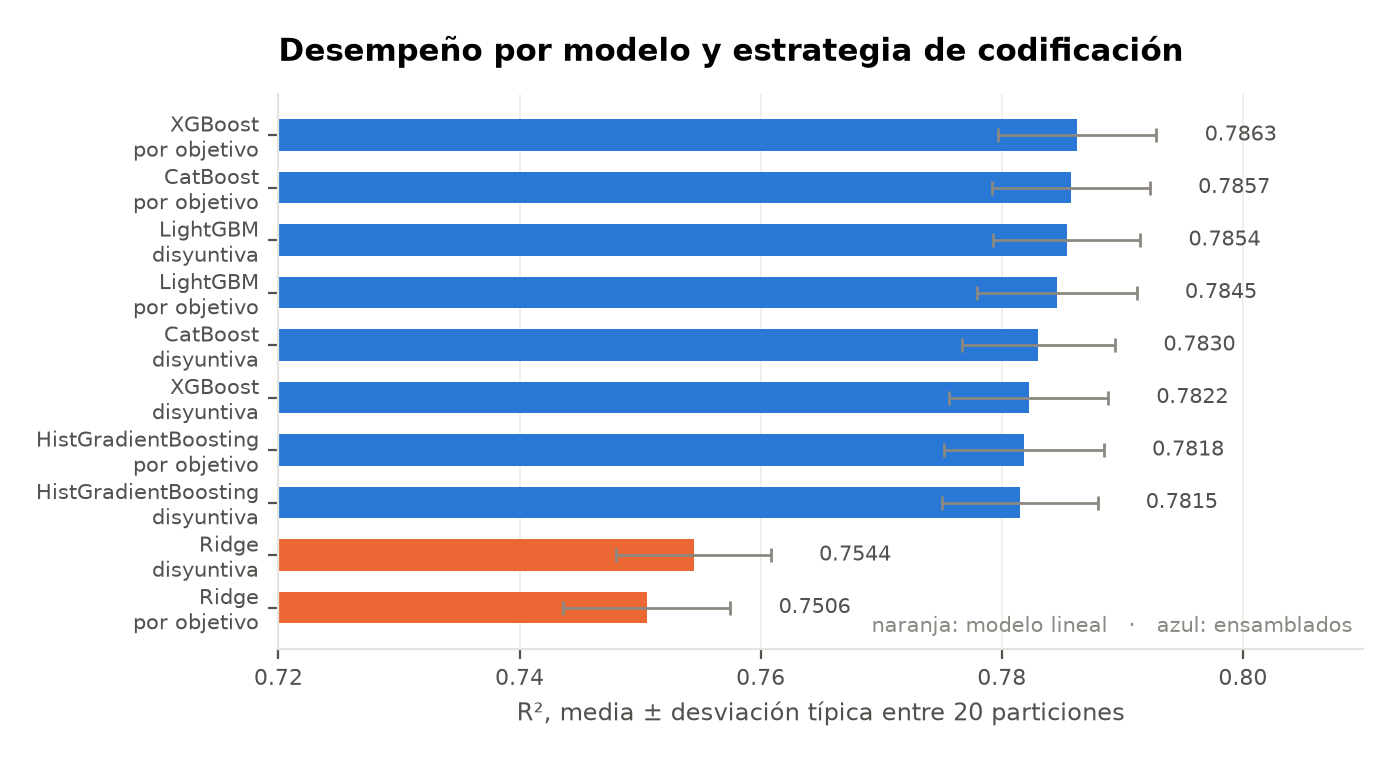

In [24]:
resumen_cv = (cv.groupby(["modelo", "codificacion"])
                .agg(R2=("R2", "mean"), desv=("R2", "std"), MAE_USD=("MAE_USD", "mean"))
                .round(4).sort_values("R2", ascending=False))
print(resumen_cv.to_string())

from scripts.generate_figures import fig_modelos
figura(fig_modelos(FIGURAS, SALIDA))

XGBoost con codificación por objetivo queda primero, 0.7863.

Lo que no esperaba es lo pegados que están: entre el primero y el quinto hay tres
milésimas de R², y la desviación típica entre particiones es de seis milésimas.
O sea que **la diferencia entre los cuatro ensamblados es más pequeña que lo que
varían ellos mismos de una partición a otra**. Quedarme con el primero por su
media y decir que es el mejor sería colarme.

Ridge se queda en 0.7544, tres puntos por debajo. Y el MAE baja de 49,826 a
24,890: la mitad del error de no hacer nada.

## 9. El conjunto de prueba

Hasta aquí no lo he tocado.

In [25]:
tuberias, filas = {}, []
for codificacion in ("target", "onehot"):
    for nombre, modelo in modelos.items():
        t = Pipeline([("preprocesador", construir_preprocesador(df, codificacion)),
                      ("modelo", clone(modelo))]).fit(X_ent, y_ent)
        m = compute_metrics(y_pru, t.predict(X_pru))
        m.update({"modelo": nombre, "codificacion": codificacion})
        filas.append(m)
        tuberias[(nombre, codificacion)] = t

prueba = pd.DataFrame(filas)
prueba.to_csv(SALIDA / "test_by_encoding.csv", index=False)
print(prueba.set_index(["modelo", "codificacion"])[["R2", "MAE_USD", "MedAE_USD", "MAPE"]]
      .round(4).sort_values("R2", ascending=False).to_string())

                                       R2     MAE_USD   MedAE_USD      MAPE
modelo               codificacion                                          
CatBoost             target        0.7865  24760.2411  14337.6181   29.0561
XGBoost              target        0.7862  24587.8122  14148.1562   28.9158
LightGBM             onehot        0.7861  24438.5289  14215.0911   28.9536
CatBoost             onehot        0.7849  24816.3887  14499.1140   29.2281
LightGBM             target        0.7844  24599.4182  14282.7949   29.0327
HistGradientBoosting target        0.7842  24785.6662  14455.2874   29.1913
                     onehot        0.7833  24704.6495  14438.5430   29.4536
XGBoost              onehot        0.7826  24743.7271  14327.2812   29.3612
Ridge                onehot        0.7537  26476.3399  15272.8387   31.5032
                     target        0.7502  26626.5366  15437.7441   31.8274
Baseline_media       onehot       -0.0002  49826.1445  34097.8890   95.7440
            

En prueba el orden cambia: se pone delante CatBoost con 0.7865 y XGBoost baja al
segundo por tres diezmilésimas.

No lo leo como que CatBoost sea mejor, sino como confirmación de lo de antes: las
diferencias están por debajo del ruido, y 7,525 observaciones bastan para
reordenarlos. Si tuviera que elegir uno para usarlo de verdad miraría el tiempo
de ajuste antes que la cuarta cifra decimal, y ahí CatBoost tarda cuatro veces
más que XGBoost.

Lo importante es que prueba y validación cruzada se parecen. Si hubiera
sobreajuste, aquí se habría notado.

  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/residuos.png


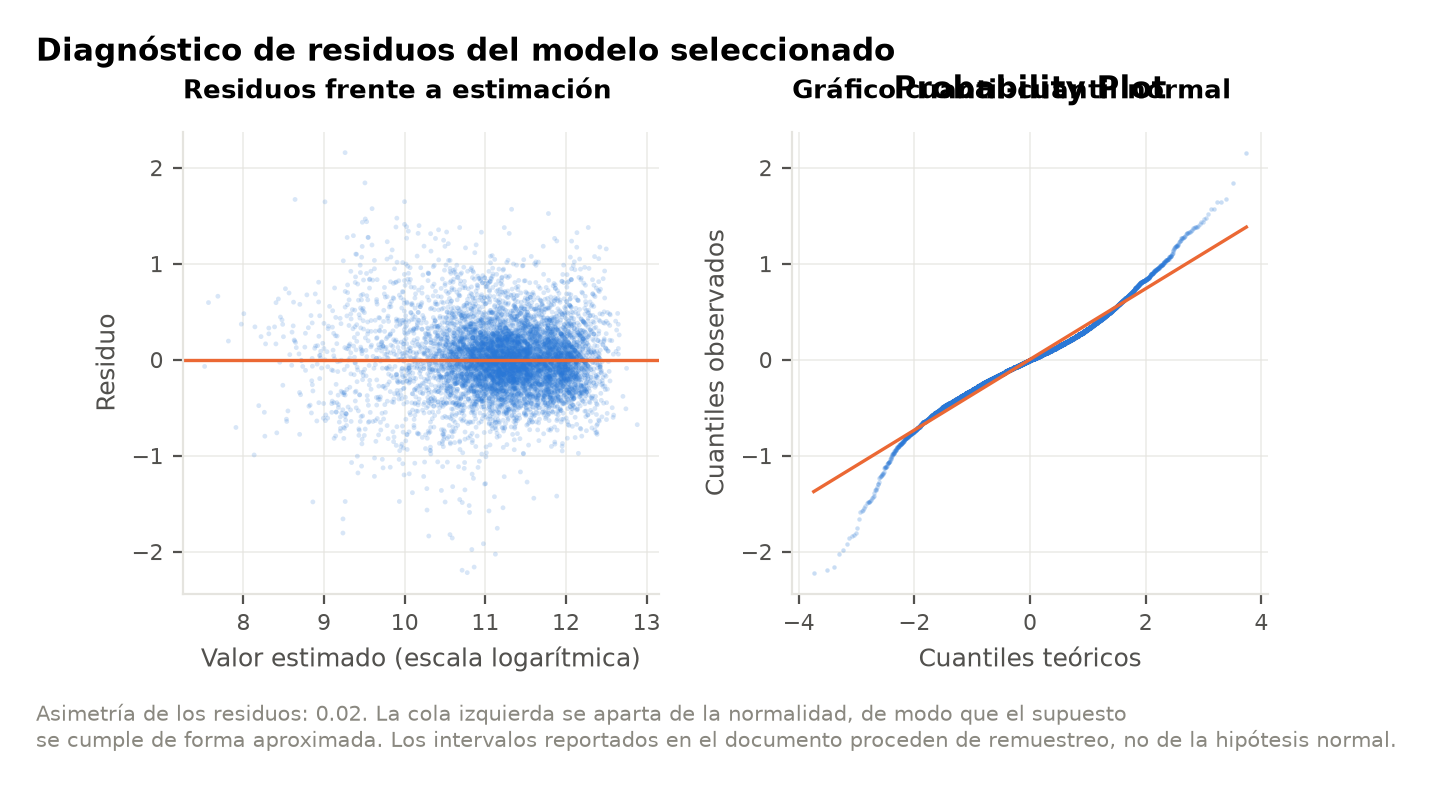

In [26]:
from scripts.generate_figures import fig_residuos
figura(fig_residuos(FIGURAS, df, SALIDA))

Los residuos están centrados y no se abren ni se cierran con el valor estimado,
que es lo que quería comprobar.

Lo que sí se ve es que no son simétricos: hay más masa por debajo. El modelo se
ajusta sobre el logaritmo y al deshacer la transformación con la exponencial el
resultado queda por debajo de la media real. Es un efecto conocido de trabajar en
logaritmos, no es que el modelo esté torcido, pero conviene tenerlo presente
porque aparecerá otra vez cuando mire el sesgo por grupos.

## 10. ¿Las diferencias son de verdad?

Tengo veinte medidas de R² por configuración, sobre las mismas particiones. La
prueba de Wilcoxon pareada compara dos configuraciones partición a partición.

In [27]:
from scipy.stats import wilcoxon

pivote = cv.pivot_table(index="particion", columns=["modelo", "codificacion"], values="R2")

# Antes de usarla, una comprobación que casi me cuesta un disgusto: con pocas
# particiones la prueba no puede dar un valor p pequeño por mucho que la
# diferencia sea grande, porque no hay combinaciones de signos suficientes.
for n in (5, 10, 20):
    x = np.arange(1, n + 1)
    print(f"  con {n:>2} pares, el menor valor p posible es {wilcoxon(x, -x).pvalue:.2g}")

  con  5 pares, el menor valor p posible es 0.062
  con 10 pares, el menor valor p posible es 0.002
  con 20 pares, el menor valor p posible es 1.9e-06


Menos mal que lo he mirado antes de usarla.

**Con cinco particiones el menor valor p que la prueba puede dar es 0.062**, por
encima del 0.05. Da igual lo grande que sea la diferencia: con cinco pares no hay
suficientes combinaciones de signos para bajar de ahí, y ninguna comparación
saldría significativa nunca.

Con veinte pares baja a 1.9 × 10⁻⁶. Por eso he repetido la validación cruzada
cuatro veces en vez de hacerla una sola.

In [28]:
def comparar(a, b, familia):
    x, y_ = pivote[a], pivote[b]
    stat, p = wilcoxon(x, y_)
    return {"familia": familia, "config_a": f"{a[0]}/{a[1]}", "config_b": f"{b[0]}/{b[1]}",
            "n_pares": len(x), "media_a": round(x.mean(), 4), "media_b": round(y_.mean(), 4),
            "diferencia": round((x - y_).mean(), 4), "p_valor": p}

reales = [m for m in modelos if not m.startswith("Baseline")]
comparaciones = []
for m in reales:                                    # ¿importa la codificación?
    comparaciones.append(comparar((m, "target"), (m, "onehot"), "codificacion"))
for c in ("target", "onehot"):                      # ¿le gano a no hacer nada?
    for m in reales:
        for base in ("Baseline_media", "Baseline_mediana"):
            comparaciones.append(comparar((m, c), (base, c), "contra_baseline"))
for c in ("target", "onehot"):                      # ¿hace falta un ensamblado?
    for m in [r for r in reales if r != "Ridge"]:
        comparaciones.append(comparar(("Ridge", c), (m, c), "lineal_vs_ensamblado"))

# Holm-Bonferroni dentro de cada familia: comparo muchas veces y sin corregir
# alguna saldría significativa por puro azar.
def holm(bloque):
    bloque = bloque.sort_values("p_valor").reset_index(drop=True)
    bloque["umbral"] = [0.05 / (len(bloque) - k) for k in range(len(bloque))]
    bloque["significativo"] = bloque["p_valor"] < bloque["umbral"]
    fallidas = bloque.index[~bloque["significativo"]]
    if len(fallidas):
        bloque.loc[fallidas.min():, "significativo"] = False
    return bloque

contrastes = pd.concat([holm(b) for _, b in pd.DataFrame(comparaciones).groupby("familia")],
                       ignore_index=True)
contrastes.to_csv(SALIDA / "wilcoxon_tests.csv", index=False)

print("¿Le gano a las líneas base?")
cb = contrastes[contrastes.familia == "contra_baseline"]
print(f"  {cb.significativo.sum()} de {len(cb)} comparaciones significativas\n")

print("¿Importa la estrategia de codificación?")
print(contrastes[contrastes.familia == "codificacion"]
      [["config_a", "config_b", "media_a", "media_b", "diferencia", "p_valor", "significativo"]]
      .to_string(index=False))

¿Le gano a las líneas base?
  20 de 20 comparaciones significativas

¿Importa la estrategia de codificación?
                   config_a                    config_b  media_a  media_b  diferencia  p_valor  significativo
               Ridge/target                Ridge/onehot   0.7506   0.7544     -0.0039 0.000002           True
             XGBoost/target              XGBoost/onehot   0.7863   0.7822      0.0040 0.000002           True
            CatBoost/target             CatBoost/onehot   0.7857   0.7830      0.0027 0.000002           True
            LightGBM/target             LightGBM/onehot   0.7845   0.7854     -0.0008 0.097307          False
HistGradientBoosting/target HistGradientBoosting/onehot   0.7818   0.7815      0.0004 0.368277          False


Las veinte comparaciones contra las líneas base salen significativas. Tampoco es
un resultado que sorprenda: la diferencia entre R² de 0.78 y R² de 0.00 no
necesitaba una prueba estadística.

Lo de la codificación es más interesante y no contesta lo que yo pensaba
preguntar. No es que una sea mejor: **depende del modelo**. La codificación por
objetivo gana en XGBoost y CatBoost, **pierde** en Ridge, y en LightGBM y
HistGradientBoosting la diferencia no es distinguible del ruido.

Que pierda en Ridge tiene sentido cuando lo piensas: un modelo lineal no puede
hacer gran cosa con una variable que resume el país en un solo número, mientras
que un árbol puede partirla por donde quiera.

Y conviene mirar la columna de diferencias antes de emocionarse: la mayor es de
0.0040 de R². Es significativa porque se repite en las veinte particiones, no
porque sea grande.

In [29]:
print("¿Hace falta un ensamblado, o basta el modelo lineal?")
print(contrastes[contrastes.familia == "lineal_vs_ensamblado"]
      [["config_a", "config_b", "diferencia", "p_valor", "significativo"]]
      .to_string(index=False))

¿Hace falta un ensamblado, o basta el modelo lineal?
    config_a                    config_b  diferencia  p_valor  significativo
Ridge/target HistGradientBoosting/target     -0.0313 0.000002           True
Ridge/target              XGBoost/target     -0.0357 0.000002           True
Ridge/target             LightGBM/target     -0.0340 0.000002           True
Ridge/target             CatBoost/target     -0.0352 0.000002           True
Ridge/onehot HistGradientBoosting/onehot     -0.0270 0.000002           True
Ridge/onehot              XGBoost/onehot     -0.0278 0.000002           True
Ridge/onehot             LightGBM/onehot     -0.0310 0.000002           True
Ridge/onehot             CatBoost/onehot     -0.0286 0.000002           True


Aquí no hay ambigüedad: los ensamblados le ganan a Ridge en las ocho
comparaciones, con diferencias de entre 0.027 y 0.036 de R². Son un orden de
magnitud mayores que las de la codificación.

O sea que la complejidad del ensamblado sí se paga con exactitud, y la elección
del modelo importa bastante más que cómo codifique las categóricas.

## 11. ¿De qué depende lo que estima?

Me quedo con la configuración que mejor salió en validación cruzada y calculo
los valores SHAP: cuánto empuja cada variable, en cada persona concreta, la
estimación arriba o abajo.

In [30]:
from src.explainability import explicar

mejor = resumen_cv.index[0]
print("Elegida:", mejor[0], "con codificación", mejor[1])

tuberia = tuberias[mejor]
shap_res = explicar(tuberia, X_ent, X_pru,
                    nombres=nombres_de_variables(tuberia.named_steps["preprocesador"]),
                    directorio=str(SALIDA), etiqueta=f"{mejor[0]}_{mejor[1]}_2023")
print(f"\nExplicador: {shap_res['estimador']} sobre {shap_res['n_explicadas']:,} observaciones")

Elegida: XGBoost con codificación target


  [XGBoost_target_2023] TreeExplainer sobre 7,525 observaciones



Explicador: TreeExplainer sobre 7,525 observaciones


  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/shap_importancia.png


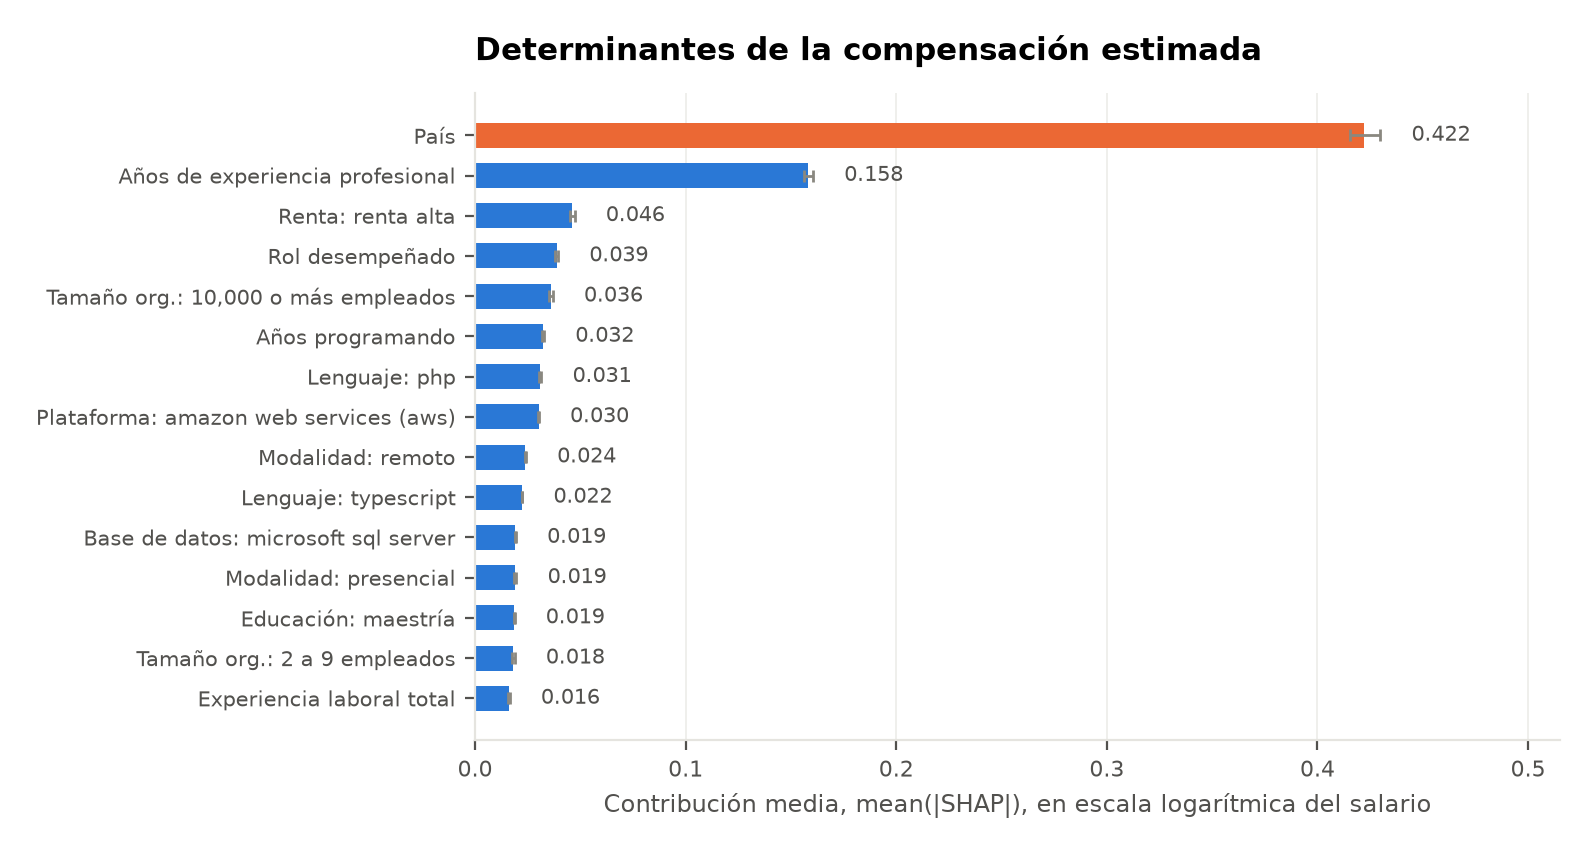

In [31]:
from scripts.generate_figures import fig_shap
figura(fig_shap(FIGURAS, SALIDA, etiqueta=f"{mejor[0]}_{mejor[1]}_2023"))

El país domina, y no por poco.

Me esperaba que la experiencia pesara más. La segunda variable son los años de
experiencia profesional, pero a menos de la mitad de la contribución del país.

In [32]:
imp = pd.read_csv(SALIDA / f"shap_summary_{mejor[0]}_{mejor[1]}_2023.csv")

# Comparo el orden que da SHAP con el de la importancia por impureza, que es la
# que los modelos de árboles traen de serie y la que suele publicarse.
from scipy.stats import spearmanr
comunes = imp.dropna(subset=["importancia_impureza"])
rho, p = spearmanr(comunes["shap_medio_abs"], comunes["importancia_impureza"])
print(f"Correlación de Spearman entre ambas ordenaciones: {rho:.3f}\n")

comparacion = comunes.head(10)[["variable", "shap_medio_abs", "importancia_impureza"]].copy()
comparacion["puesto SHAP"] = range(1, len(comparacion) + 1)
comparacion["puesto impureza"] = (comunes["importancia_impureza"]
                                  .rank(ascending=False).head(10).astype(int).values)
print(comparacion.round(4).to_string(index=False))

Correlación de Spearman entre ambas ordenaciones: 0.749

                           variable  shap_medio_abs  importancia_impureza  puesto SHAP  puesto impureza
                            Country          0.4223                0.1353            1                2
                   YearsCodePro_num          0.1583                0.0353            2                3
           income_group_High income          0.0461                0.2133            3                1
                            DevType          0.0387                0.0072            4               17
   OrgSize_10,000 or more employees          0.0361                0.0172            5                7
                      YearsCode_num          0.0322                0.0050            6               31
                      language__php          0.0308                0.0200            7                6
platform__amazon_web_services_(aws)          0.0302                0.0222            8                5
       

Esto merece pararse.

La correlación entre las dos ordenaciones es 0.749: alta, pero muy lejos de 1. Y
mirando la tabla se ve dónde se rompen.

`income_group_High income` es **primera** por impureza y **tercera** por SHAP.
`YearsCode_num` es sexta por SHAP y **trigésimo primera** por impureza.
`DevType`, cuarta por SHAP, es la diecisiete por impureza.

Son dos cosas distintas. La importancia por impureza mide cuánto usa el modelo
una variable para partir; SHAP mide cuánto mueve la estimación. Una variable
puede aparecer en muchos cortes y mover poco, o al revés.

Lo anoto porque es fácil publicar la de impureza llamándola SHAP: la trae el
modelo de serie, sale en una línea, y a simple vista parece lo mismo. No lo es.

In [33]:
# Agrupo las variables por bloques para ver el peso de cada tipo de información.
def bloque(v):
    if v.startswith(("language__", "database__", "platform__", "webframe__")):
        return "Tecnologías"
    if v.startswith(("Country", "income_group", "wb_region")):
        return "Geográfico"
    if v.startswith(("YearsCode", "WorkExp", "EdLevel", "DevType", "ICorPM")):
        return "Capital humano"
    if v.startswith(("Age", "Gender")):
        return "Demográfico"
    return "Organizacional"

por_bloque = (imp.assign(bloque=imp["variable"].map(bloque))
                 .groupby("bloque")["shap_medio_abs"].agg(["sum", "size"])
                 .sort_values("sum", ascending=False))
por_bloque["% del total"] = (por_bloque["sum"] / por_bloque["sum"].sum() * 100).round(1)
print(por_bloque.round(4).to_string())

                   sum  size  % del total
bloque                                   
Geográfico      0.4788     4         35.3
Tecnologías     0.3554   106         26.2
Capital humano  0.3010    15         22.2
Organizacional  0.2021    30         14.9
Demográfico     0.0202     7          1.5


Cuatro variables geográficas se llevan el 35 % de la contribución. Las 106
columnas de tecnologías, juntas, el 26 %.

Y el bloque demográfico se queda en el **1.5 %** con siete variables: la edad y lo
que la acompaña casi no intervienen. Conviene recordarlo cuando mire la equidad.

Dicho de otro modo: dónde vives pesa más que lo que sabes hacer. No es una
conclusión cómoda pero es lo que dicen los números.

## 12. ¿El efecto de una variable depende de otra?

La importancia por variable da un solo número por variable, así que no puede
contestar a esto. Los valores SHAP sí, porque dan una atribución por persona.

In [34]:
from run_interacciones import fuerza_interaccion

datos = np.load(SALIDA / f"shap_values_{mejor[0]}_{mejor[1]}_2023.npz", allow_pickle=True)
valores, nombres_var = datos["shap_values"], list(datos["feature_names"])

# El explicador guarda qué filas usó; hay que quedarse con esas mismas y en el
# mismo orden, o los valores SHAP quedarían emparejados con otras personas.
X_t = np.asarray(tuberia.named_steps["preprocesador"].transform(X_pru), dtype=float)
X_t = X_t[datos["indices"]]

top = imp.head(12)["variable"].tolist()
pares = []
for vi in top:
    for vj in top:
        if vi == vj:
            continue
        pares.append({"contribución de": vi, "varía según": vj,
                      "fuerza": round(fuerza_interaccion(
                          valores, X_t, nombres_var.index(vi), nombres_var.index(vj)), 4)})

inter = pd.DataFrame(pares).sort_values("fuerza", ascending=False)
inter.to_csv(SALIDA / "interacciones.csv", index=False)
print(inter.head(10).to_string(index=False))

               contribución de      varía según  fuerza
      income_group_High income          Country  1.2354
              YearsCodePro_num    YearsCode_num  0.9600
                 YearsCode_num YearsCodePro_num  0.9446
      income_group_High income    YearsCode_num  0.3158
      income_group_High income YearsCodePro_num  0.2692
          language__typescript          DevType  0.2651
                       Country    YearsCode_num  0.2433
                       Country YearsCodePro_num  0.2144
database__microsoft_sql_server          DevType  0.2127
                 YearsCode_num          DevType  0.1935


Los tres primeros pares no me sirven y conviene verlos antes de seguir.

`income_group_High income` con `Country` es lo mismo dos veces: el nivel de renta
se deriva del país. Y las dos medidas de antigüedad entre sí, igual. Cuando dos
variables miden lo mismo, el modelo reparte la atribución entre ellas de forma
inestable, y esta medida lee ese vaivén como si fuera una interacción.

In [35]:
# Los pares de arriba incluyen variables que miden lo mismo. Las tres medidas de
# antigüedad están correlacionadas entre sí, y el nivel de renta se deriva del
# país, así que su "interacción" es solo que el modelo reparte la atribución
# entre ellas de forma inestable. Los quito.
redundantes = [
    {"YearsCode_num", "YearsCodePro_num", "WorkExp_num"},
    {"Country", "income_group_High income"},
]
def es_redundante(f):
    return any({f["contribución de"], f["varía según"]} <= grupo for grupo in redundantes)

print(f"Correlación entre las medidas de antigüedad: "
      f"{X[['YearsCode_num', 'YearsCodePro_num']].corr().iloc[0, 1]:.3f}\n")

sustantivas = inter[~inter.apply(es_redundante, axis=1)]
print(sustantivas.head(8).to_string(index=False))

Correlación entre las medidas de antigüedad: 0.919

               contribución de      varía según  fuerza
      income_group_High income    YearsCode_num  0.3158
      income_group_High income YearsCodePro_num  0.2692
          language__typescript          DevType  0.2651
                       Country    YearsCode_num  0.2433
                       Country YearsCodePro_num  0.2144
database__microsoft_sql_server          DevType  0.2127
                 YearsCode_num          DevType  0.1935
                       Country          DevType  0.1751


Quitando los pares redundantes, la interacción más fuerte es la del nivel de
renta del país con los años de experiencia, por los dos lados.

Traducido: **cuánto te paga la experiencia depende del mercado en el que estés**.
No es una tecnicidad, es una afirmación con contenido económico, y quiero verla.

  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/interaccion_experiencia_renta.png


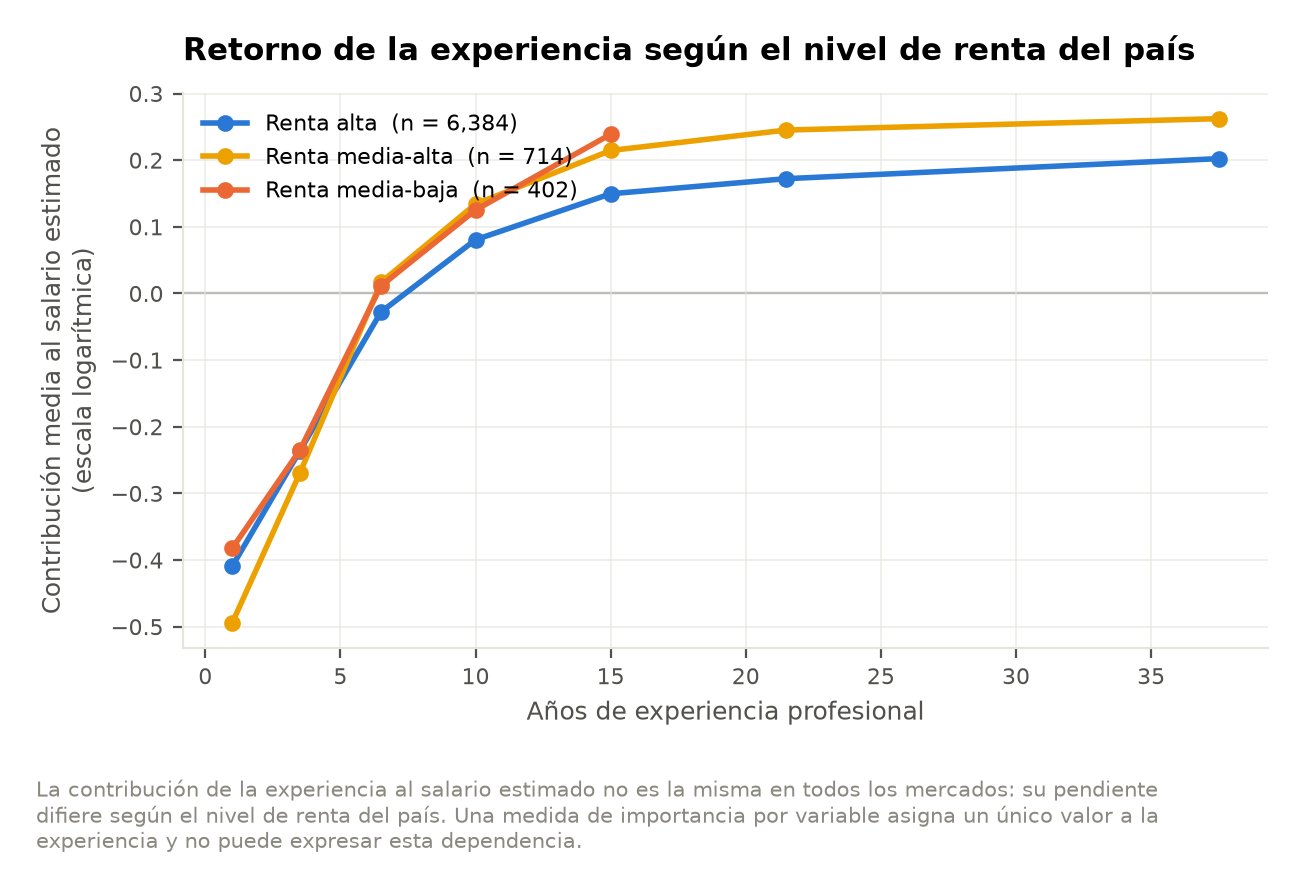

In [36]:
from scripts.generate_figures import fig_interaccion_experiencia
figura(fig_interaccion_experiencia(FIGURAS, SALIDA, df))

Ahí está, y es más clara de lo que esperaba.

Los primeros años son iguales en los tres grupos: la contribución es negativa
(empezar cobra menos que la media, evidentemente) y prácticamente la misma en
todas partes. A partir del décimo año las curvas se separan. En los países de
renta media-alta la experiencia sigue sumando; en los de renta alta la curva se
aplana antes. Hacia los veinte años de experiencia, 0.245 frente a 0.172.

Lo que me interesa de esto es que **ninguna medida de importancia por variable
puede decirlo**. Le daría a la experiencia un solo número, promediando tres
trayectorias distintas y perdiendo justo lo que las diferencia.

## 13. ¿Funciona igual para todos?

El R² de 0.79 es una media sobre todo el conjunto de prueba. Una media puede
esconder que el modelo funcione muy bien para la mayoría y mal para una minoría,
así que hay que mirarlo por grupos.

In [37]:
pred = tuberia.predict(X_pru)

# Todo en dólares, no en logaritmos: un error de 0.3 en escala logarítmica no
# significa nada, y además la comparación entre grupos sería engañosa.
real_usd, pred_usd = np.expm1(y_pru), np.expm1(pred)

por_renta = pd.DataFrame({"grupo": A_pru["income_group"].values,
                          "real": real_usd, "pred": pred_usd})
tabla = por_renta.groupby("grupo").apply(lambda g: pd.Series({
    "N": len(g),
    "Mediana real": g["real"].median(),
    "MAE": (g["pred"] - g["real"]).abs().mean(),
}), include_groups=False)
print(tabla.round(0).to_string())
print(f"\nRazón entre el mayor y el menor MAE: "
      f"{tabla['MAE'].max() / tabla['MAE'].min():.2f}")

                          N  Mediana real      MAE
grupo                                             
High income          6406.0       88173.0  26286.0
Lower middle income   403.0       16964.0   9846.0
Upper middle income   716.0       34350.0  17688.0

Razón entre el mayor y el menor MAE: 2.67


El 0.79 de R² era una media, y aquí se ve lo que escondía.

El error en los países de renta alta es de 26,286 dólares y en los de renta
media-baja de 9,846: casi tres veces más en los ricos. Leído tal cual, el modelo
funcionaría mucho peor con los países ricos.

No me lo creo. Los salarios de renta alta son cinco veces mayores, así que es
normal que el error en dólares también lo sea. Comparar errores absolutos entre
grupos que cobran cosas tan distintas no puede estar bien.

In [38]:
# Divido el error de cada grupo por su propia mediana.
tabla["MAE / mediana"] = tabla["MAE"] / tabla["Mediana real"]
print(tabla.round(3).to_string())
print(f"\nRazón con el error absoluto: {tabla['MAE'].max() / tabla['MAE'].min():.2f}"
      f"   peor: {tabla['MAE'].idxmax()}")
print(f"Razón con el error relativo: "
      f"{tabla['MAE / mediana'].max() / tabla['MAE / mediana'].min():.2f}"
      f"   peor: {tabla['MAE / mediana'].idxmax()}")

                          N  Mediana real        MAE  MAE / mediana
grupo                                                              
High income          6406.0       88173.0  26286.440          0.298
Lower middle income   403.0       16964.0   9845.779          0.580
Upper middle income   716.0       34350.0  17687.853          0.515

Razón con el error absoluto: 2.67   peor: High income
Razón con el error relativo: 1.95   peor: Lower middle income


Efectivamente, **se da la vuelta**.

En proporción al salario típico de cada sitio, el modelo se equivoca un 29.8 % en
los países de renta alta y un **58.0 %** en los de renta media-baja. El doble. El
grupo peor servido no es el que decía el error absoluto: es justo el contrario.

La razón de disparidad baja de 2.67 a 1.95, pero las dos superan cualquier umbral
razonable, así que la disparidad existe de las dos maneras. Lo que cambia, y es
lo importante, es **a quién perjudica**.

Si hubiera hecho la auditoría con el error en dólares habría escrito la
conclusión contraria a la correcta, y encima habría sonado convincente.

In [39]:
from src.fairness import auditar, resumir
import json

for atributo in ("income_group", "wb_region", "Age", "EdLevel", "OrgSize"):
    aud = auditar(y_pru, pred, A_pru[atributo])
    (SALIDA / f"fairness_{atributo}_2023.json").write_text(
        json.dumps(aud, ensure_ascii=False, indent=1), encoding="utf-8")
print(resumir(auditar(y_pru, pred, A_pru["wb_region"]), "Región"))

Auditoría de equidad — Región
  N = 7,525 · grupos: 7 (7 con tamaño suficiente)

  grupo                           N        MAE  MAE/mediana       sesgo
  Latin America & Caribbean     347     19,045        58.7 %      -6,582
  South Asia                    349     10,209        54.9 %      -5,577
  Middle East, North Africa,    183     20,120        34.2 %      -3,423
  Sub-Saharan Africa             60     13,338        33.6 %      -7,337
  North America               2,429     40,067        28.6 %      -9,494
  Europe & Central Asia       3,681     17,444        27.0 %      -3,405
  East Asia & Pacific           476     18,560        25.2 %      -5,264

  Razón de disparidad RELATIVA .. 2.332   SUPERA el umbral de 1.25
  Peor servido (relativo) ....... Latin America & Caribbean
  Coef. de variación relativo ... 0.337

  [Referencia] razón absoluta ... 3.925  · peor servido: North America
  ⚠ El grupo peor servido cambia al normalizar por la escala salarial:
    el error absoluto no 

  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/equidad_por_region.png


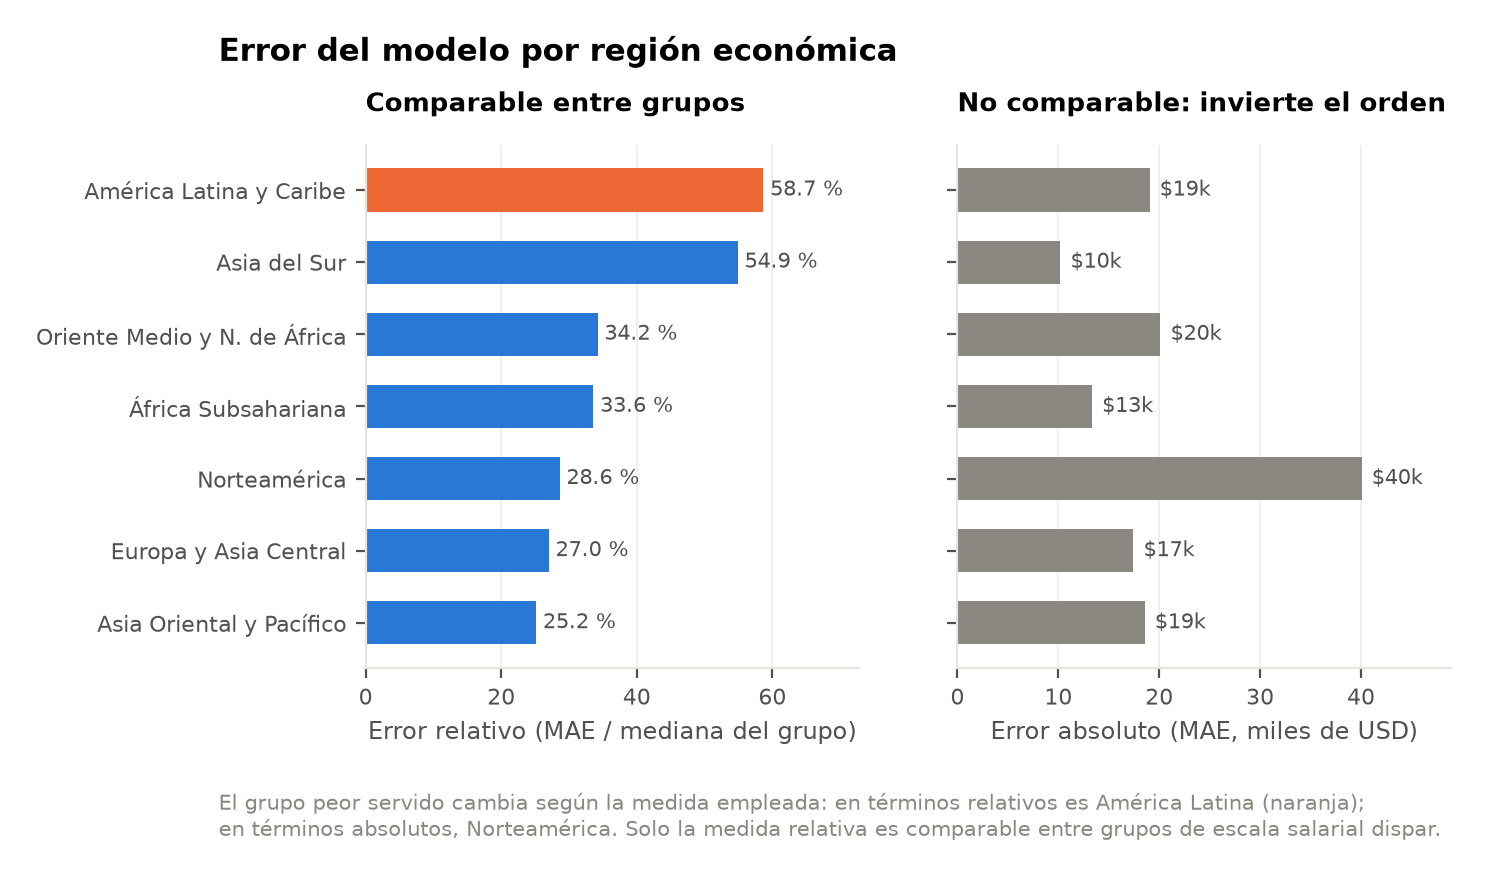

In [40]:
from scripts.generate_figures import fig_equidad
figura(fig_equidad(FIGURAS, SALIDA, anio="2023"))

Por región se ve lo mismo y más marcado. América Latina, 58.7 % de error
relativo; Asia del Sur, 54.9 %; Europa y Asia Oriental, entre 25 y 27 %.

Dos cosas más del resumen. La prueba de Kruskal-Wallis da p = 5.9 × 10⁻⁶: la
diferencia entre regiones no es casualidad del reparto. Y la distancia de
Kolmogórov-Smirnov entre Norteamérica y Asia del Sur es 0.995, o sea que las
compensaciones que el modelo predice para una y otra región no se solapan
prácticamente nada.

El sesgo es negativo en todos los grupos sin excepción, que es el efecto de la
exponencial que ya salía en los residuos. Como afecta a todos por igual, no es
una diferencia de trato entre grupos.

## 14. El género, que hay que ir a buscar a 2022

La edición 2023 no pregunta por género. La de 2022 sí, así que repito sobre ella
lo imprescindible.

In [41]:
df22, _ = cargar_encuesta(anio="2022")
print(f"Edición 2022: {len(df22):,} observaciones efectivas")
print(df22["Gender"].value_counts().head(4).to_string())

X22, y22, A22 = preparar_xy(df22)
Xe, Xp, ye, yp, _, Ap = train_test_split(
    X22, y22, A22, test_size=0.20, random_state=SEMILLA, stratify=df22["income_group"])
t22 = Pipeline([("preprocesador", construir_preprocesador(df22, mejor[1])),
                ("modelo", clone(modelos[mejor[0]]))]).fit(Xe, ye)
p22 = t22.predict(Xp)
print(f"\nR² sobre prueba: {compute_metrics(yp, p22)['R2']:.4f}")

aud_g = auditar(yp, p22, Ap["Gender"])
(SALIDA / "fairness_Gender_2022.json").write_text(
    json.dumps(aud_g, ensure_ascii=False, indent=1), encoding="utf-8")
print()
print(resumir(aud_g, "Género"))

Edición 2022: 28,951 observaciones efectivas
Gender
Man                                                  26705
Woman                                                 1333
No declarado                                           342
Non-binary, genderqueer, or gender non-conforming      251



R² sobre prueba: 0.7799

Auditoría de equidad — Género
  N = 5,791 · grupos: 11 (4 con tamaño suficiente)

  grupo                           N        MAE  MAE/mediana       sesgo
  Or, in your own words:;Wom      1     57,841       176.6 %     +57,841  (descriptivo)
  No declarado                   70     36,300        48.6 %     -16,587
  Non-binary, genderqueer, o     47     30,175        41.3 %      -6,255
  Woman                         286     23,140        36.2 %      -1,563
  Man                         5,310     23,449        36.0 %      -7,289
  Man;Non-binary, genderquee     20     27,852        34.7 %      +3,120  (descriptivo)
  Or, in your own words:         21     23,632        34.2 %      +5,538  (descriptivo)
  Man;Or, in your own words:     13     18,525        30.2 %      -3,527  (descriptivo)
  Woman;Non-binary, genderqu     16     22,669        25.8 %      -1,572  (descriptivo)
  Or, in your own words:;Non      3     11,339        25.1 %     +10,966  (descriptivo)


La edición 2022 tiene 28,951 observaciones válidas, bastantes menos que 2023, y
el R² sale 0.7799, muy parecido. Al menos el modelo se comporta igual en las dos.

La tabla sale con once grupos porque la pregunta permite marcar varias opciones a
la vez, y la mayoría de las combinaciones tienen dos o tres personas. La función
las marca como descriptivas y las deja fuera de la inferencia. Aun así ensucian
la lectura, así que me quedo con los cuatro que pasan de treinta.

In [42]:
# Junto el error del modelo con el salario real, que son las dos cosas que hay
# que mirar a la vez.
g = pd.DataFrame(aud_g["por_grupo"]).T
g = g[g["n"].astype(int) >= 30]
mediana = (pd.DataFrame({"g": Ap["Gender"].values, "y": np.expm1(yp)})
             .groupby("g")["y"].median())
print(pd.DataFrame({
    "N": g["n"].astype(int),
    "Mediana real (USD)": mediana.reindex(g.index).round(0),
    "MAE relativo": g["mae_relativo"].astype(float).round(3),
}).sort_values("N", ascending=False).to_string())

                                                      N  Mediana real (USD)  MAE relativo
Man                                                5310             65053.0         0.360
Woman                                               286             63855.0         0.362
No declarado                                         70             74756.0         0.486
Non-binary, genderqueer, or gender non-conforming    47             73000.0         0.413


Esto es lo que quería ver, y contesta a la pregunta que motivaba toda la
auditoría.

Hombres, 0.360 de error relativo. Mujeres, 0.362. **Dos milésimas**, sobre 5,310
y 286 observaciones.

Y a la vez la mediana real de las mujeres está por debajo de la de los hombres.
O sea que la brecha salarial **está en los datos**, pero **no está en el error del
modelo**: el sistema estima igual de bien a unas y a otros. Lo que reproduce es un
mercado desigual, no una desigualdad propia.

Son dos cosas que se confunden con facilidad y llevan a conclusiones opuestas.

Sobre la razón de disparidad de 1.347 que sale en el resumen: no viene de este
contraste, viene de las setenta personas que no declararon género (0.486) y las
cuarenta y siete no binarias (0.413). Si cito ese número suelto estoy diciendo
algo que los datos no dicen.

In [43]:
# Y cruzando género con región, que es donde la literatura dice que aparece lo
# que el agregado esconde.
lat = A22.loc[Xp.index, "wb_region"] == "Latin America & Caribbean"
gen = Ap["Gender"]
filas = []
for region, mascara in [("América Latina", lat), ("Resto del mundo", ~lat)]:
    for etiqueta, valor in [("Hombres", "Man"), ("Mujeres", "Woman")]:
        sel = mascara & (gen == valor)
        if sel.sum() == 0:
            continue
        real, prd = np.expm1(yp[sel.values]), np.expm1(p22[sel.values])
        filas.append({"Región": region, "Género": etiqueta, "N": int(sel.sum()),
                      "Mediana real": round(float(np.median(real))),
                      "MAE": round(float(np.abs(prd - real).mean())),
                      "MAE relativo": round(float(np.abs(prd - real).mean() / np.median(real)), 3)})
print(pd.DataFrame(filas).to_string(index=False))

         Región  Género    N  Mediana real   MAE  MAE relativo
 América Latina Hombres  362         27054 14798         0.547
 América Latina Mujeres   17         24924 17923         0.719
Resto del mundo Hombres 4948         69186 24082         0.348
Resto del mundo Mujeres  269         65053 23470         0.361


Y cruzando las dos cosas aparece lo que el agregado escondía.

Fuera de América Latina, hombres 0.348 y mujeres 0.361: una diferencia de poco más
de un punto. Dentro de América Latina, hombres 0.547 y mujeres **0.719**:
diecisiete puntos.

Ahora bien, **son diecisiete mujeres**. Con ese número no puedo afirmar nada:
cualquier diferencia de esa magnitud cabe dentro de la variabilidad de una muestra
tan pequeña. Lo dejo como descriptivo y como indicación de por dónde habría que
mirar con más datos.

Quitarlo tampoco me parece bien. Sería esconder justo el cruce que la literatura
señala como el más fácil de perder de vista.

## 15. ¿Se puede arreglar la disparidad?

Lo primero que se suele proponer es reequilibrar la muestra. Pruebo tres formas.

In [44]:
from run_mitigacion import pesos_inversos, remuestrear

rng = np.random.default_rng(SEMILLA)
g_ent = df.loc[X_ent.index, "income_group"].astype(str)
resultados_mit = []

for estrategia in ("sin_mitigacion", "reponderacion", "submuestreo", "sobremuestreo"):
    t = Pipeline([("preprocesador", construir_preprocesador(df, mejor[1])),
                  ("modelo", clone(modelos[mejor[0]]))])
    if estrategia == "reponderacion":
        t.fit(X_ent, y_ent, modelo__sample_weight=pesos_inversos(g_ent))
        Xm, ym = X_ent, y_ent
    elif estrategia == "sin_mitigacion":
        t.fit(X_ent, y_ent); Xm, ym = X_ent, y_ent
    else:
        # remuestrear devuelve índices, no la tabla ya remuestreada.
        idx = remuestrear(X_ent, y_ent, g_ent, estrategia, rng)
        Xm, ym = X_ent.iloc[idx], y_ent[idx]
        t.fit(Xm, ym)
    p = t.predict(X_pru)
    a = auditar(y_pru, p, A_pru["income_group"])
    m = compute_metrics(y_pru, p)
    resultados_mit.append({
        "estrategia": estrategia, "n_entrenamiento": len(Xm),
        "R2": round(m["R2"], 4), "MAE_log": round(m["MAE_log"], 4),
        "MAE_USD": round(m["MAE_USD"]), "MAPE": round(m["MAPE"], 2),
        "razon_disparidad_renta": round(a["agregados"]["razon_disparidad_relativa"], 3),
        "razon_disparidad_region": round(
            auditar(y_pru, p, A_pru["wb_region"])["agregados"]["razon_disparidad_relativa"], 3),
        "cv_relativo_renta": round(a["agregados"]["coeficiente_variacion_relativo"], 3),
        "peor_grupo": a["agregados"]["grupo_peor_servido_relativo"],
        "relativo_por_grupo": {k: round(v["mae_relativo"], 4)
                               for k, v in a["por_grupo"].items()},
    })
    print(f"{estrategia:16} N={len(Xm):>6,}  R²={m['R2']:.4f}  "
          f"razón={a['agregados']['razon_disparidad_relativa']:.3f}")

mit = pd.DataFrame(resultados_mit)
mit.drop(columns="relativo_por_grupo").to_csv(SALIDA / "mitigacion_resultados.csv", index=False)

sin_mitigacion   N=30,097  R²=0.7862  razón=1.947


reponderacion    N=30,097  R²=0.7816  razón=1.932


submuestreo      N= 4,842  R²=0.7506  razón=1.815


sobremuestreo    N=76,863  R²=0.7782  razón=1.933


Ninguna de las tres funciona.

La reponderación y el sobremuestreo mueven la razón de disparidad de 1.947 a 1.932
y 1.933: una centésima y media. El submuestreo sí la baja de verdad, a 1.815, pero
pagando 0.036 de R² y **tirando el 84 % de los datos de entrenamiento** (de 30,097
a 4,842).

O sea que lo único que mueve la aguja lo hace empeorando el modelo. Mal negocio.

In [45]:
# Lo que de verdad importa no es la razón, sino si los grupos pequeños mejoran.
detalle = pd.DataFrame({r["estrategia"]: r["relativo_por_grupo"] for r in resultados_mit})
print((detalle * 100).round(1).to_string())

                     sin_mitigacion  reponderacion  submuestreo  sobremuestreo
High income                    29.8           30.3         32.6           30.4
Lower middle income            58.0           58.6         59.2           58.8
Upper middle income            51.5           51.7         53.6           51.9


Y aquí está el detalle que lo explica, que es lo que de verdad importa.

**El error de los grupos pequeños no mejora con ninguna estrategia. Empeora
ligeramente con todas.** Renta media-baja pasa de 58.0 % a 58.6, 58.8 y 59.2 %.

Entonces, ¿por qué baja la razón de disparidad con el submuestreo? Porque el
grupo mayoritario empeora más (de 29.8 a 32.6 %). La razón mejora **estropeando al
grande**, no arreglando a los pequeños. Es una mejora de la métrica que no
corresponde a ninguna mejora real para nadie.

                     desv. típica intra-país  razón frente a renta alta
income_group                                                           
High income                            0.477                      1.000
Lower middle income                    0.781                      1.638
Upper middle income                    0.756                      1.586


  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/mitigacion_compromiso.png


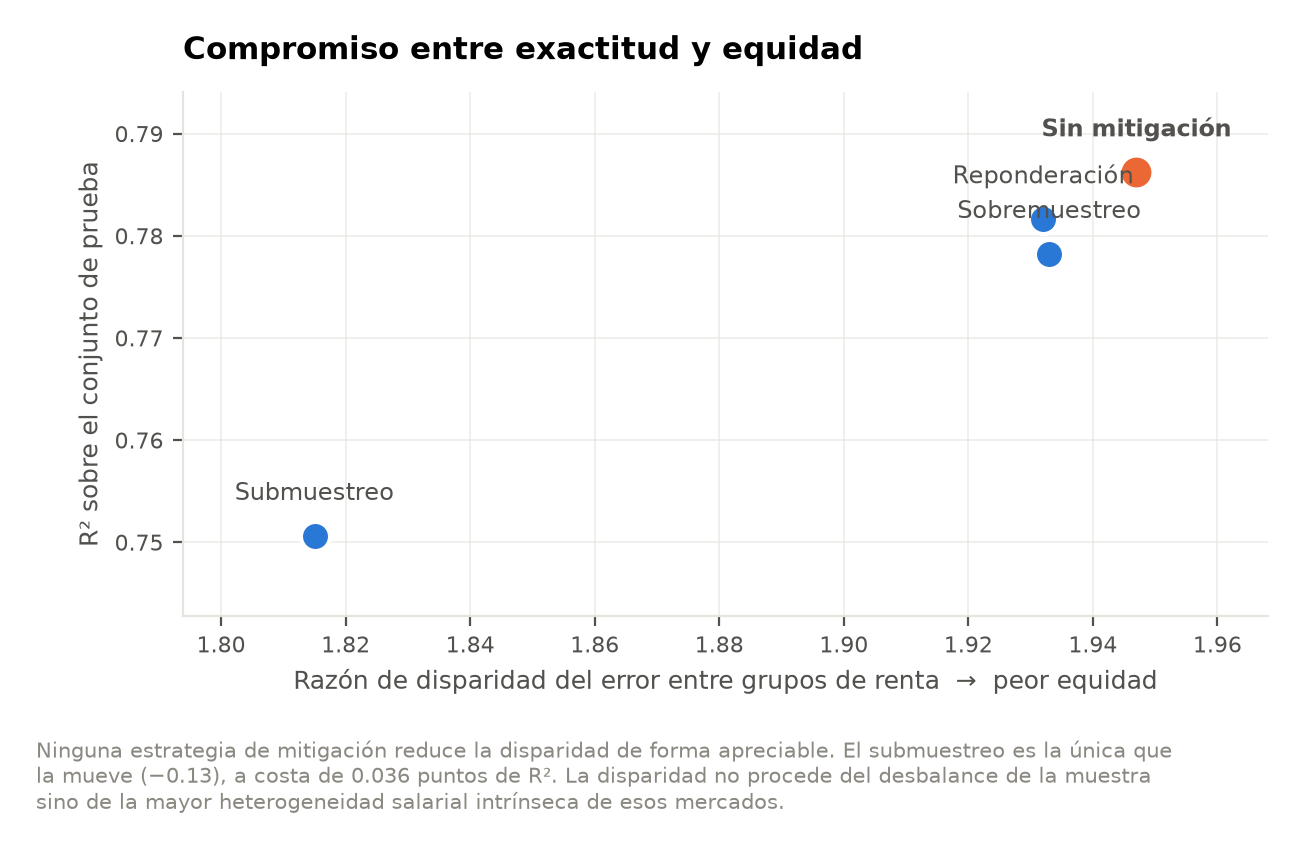

In [46]:
# Si no es un problema de representación, ¿de qué es? Miro cuánto varía el
# salario DENTRO de cada país, que es lo que el modelo tendría que explicar.
disp = (df.groupby("income_group", observed=True)
          .apply(lambda g: g.groupby("Country")["salary_log"].std().median(),
                 include_groups=False)
          .rename("desv. típica intra-país").to_frame())
disp["razón frente a renta alta"] = (disp["desv. típica intra-país"] /
                                     disp.loc["High income", "desv. típica intra-país"])
print(disp.round(3).to_string())

from scripts.generate_figures import fig_mitigacion
figura(fig_mitigacion(FIGURAS, SALIDA))

Aquí está el porqué, y me parece el hallazgo más útil de todo el trabajo.

La desviación típica del salario **dentro de cada país** es 0.477 en los de renta
alta y 0.781 en los de renta media-baja: un 64 % mayor. Dos personas del mismo
país, con perfiles parecidos según lo que la encuesta pregunta, cobran cosas mucho
más distintas en un país de renta media-baja.

Es decir: el mayor error relativo del modelo en esas regiones **no es que las trate
peor, es que el salario allí es menos predecible con las variables que hay**.
Ningún remuestreo puede arreglar aquello para lo que no hay señal en los datos.

Y la comprobación es barata: comparar la varianza de la variable objetivo dentro de
cada grupo antes de ponerse a remuestrear. Si hubiera empezado por ahí me habría
ahorrado las tres pruebas.

## 16. La inteligencia artificial, en la edición 2025

La edición 2025 es la primera que pregunta por el uso de herramientas de IA.

In [47]:
df25, _ = cargar_encuesta(anio="2025")
print(f"Edición 2025: {len(df25):,} observaciones efectivas")
print(df25["AISelect"].value_counts().to_string())

Edición 2025: 15,340 observaciones efectivas
AISelect
Yes, I use AI tools daily                      7445
Yes, I use AI tools weekly                     2758
No, and I don't plan to                        2172
Yes, I use AI tools monthly or infrequently    1976
No, but I plan to soon                          643


In [48]:
# Primero la asociación en bruto: ¿cobra distinto quien usa IA?
from run_analysis import analizar_ia
ia = analizar_ia(df25, SALIDA)
print(ia[ia.variable == "AISelect"][["categoria", "n", "mediana_usd"]].to_string(index=False))

                                  categoria    n  mediana_usd
                     No, but I plan to soon  643      89331.0
                    No, and I don't plan to 2172      87550.0
Yes, I use AI tools monthly or infrequently 1976      84845.5
                 Yes, I use AI tools weekly 2758      82240.5
                  Yes, I use AI tools daily 7445      81685.0


Sale lo contrario de lo que uno esperaría: **quien más usa IA es quien menos
cobra**. Mediana de 81,685 dólares con uso diario, frente a 87,550 entre quienes
no la usan ni piensan usarla.

No me lo tomo en serio todavía. Quien usa IA a diario puede ser sistemáticamente
más joven, o estar en otro país, o en otro tipo de empresa. La asociación bruta no
descarta nada de eso.

In [49]:
# Ahora la pregunta de verdad: ¿aporta algo la IA una vez que el modelo ya sabe
# el país, la experiencia y el rol?
X25, y25, A25 = preparar_xy(df25)
Xe25, Xp25, ye25, yp25 = train_test_split(
    X25, y25, test_size=0.20, random_state=SEMILLA, stratify=df25["income_group"])
t25 = Pipeline([("preprocesador", construir_preprocesador(df25, mejor[1])),
                ("modelo", clone(modelos[mejor[0]]))]).fit(Xe25, ye25)
res25 = explicar(t25, Xe25, Xp25,
                 nombres=nombres_de_variables(t25.named_steps["preprocesador"]),
                 directorio=str(SALIDA), etiqueta=f"{mejor[0]}_{mejor[1]}_2025")

imp25 = pd.read_csv(SALIDA / f"shap_summary_{mejor[0]}_{mejor[1]}_2025.csv")
ia_vars = imp25[imp25["variable"].str.startswith(("AISelect", "AIThreat", "AIAgents", "LearnCodeAI"))]
print(f"R² sobre prueba (2025): {compute_metrics(yp25, t25.predict(Xp25))['R2']:.4f}\n")
print(f"Variables de IA tras codificar: {len(ia_vars)}")
print(f"Contribución conjunta: {ia_vars['shap_medio_abs'].sum():.4f}")
print(f"Contribución del país: {imp25[imp25.variable.str.startswith('Country')]['shap_medio_abs'].sum():.4f}")
print(f"\nLa de mayor peso entre las de IA ocupa el puesto "
      f"{int(imp25['variable'].tolist().index(ia_vars.iloc[0]['variable'])) + 1} de {len(imp25)}.")

  [XGBoost_target_2025] TreeExplainer sobre 3,068 observaciones


R² sobre prueba (2025): 0.7975

Variables de IA tras codificar: 23
Contribución conjunta: 0.0653
Contribución del país: 0.4312

La de mayor peso entre las de IA ocupa el puesto 16 de 192.


  /home/debugsito/Documents/local/tesis/tech-salary-prediction/salida_cuaderno/figures/ia_compensacion.png


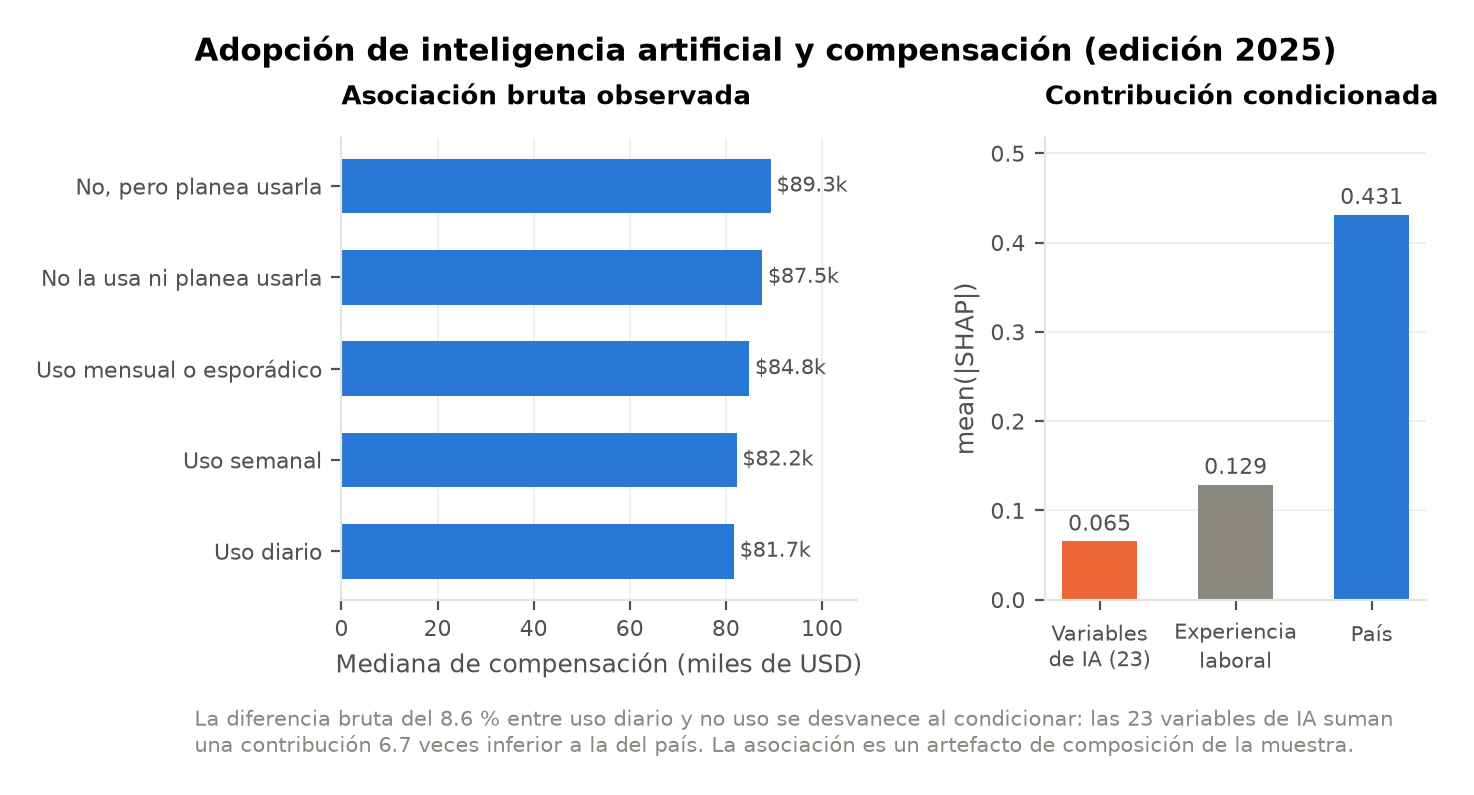

In [50]:
from scripts.generate_figures import fig_ia
figura(fig_ia(FIGURAS, SALIDA))

Condicionando por lo demás, la asociación se deshace.

Las 23 variables de IA juntas suman 0.0653 de contribución. El país solo, 0.4312:
**seis veces y media más que las de IA todas juntas**. La de más peso entre ellas
es la decimosexta de 192.

Así que la relación del primer gráfico era composición de la muestra, no efecto de
la IA. Quien la usa a diario tiene un perfil distinto, y es ese perfil el que
explica el sueldo.

Dicho esto, y para no pasarme: esto son datos de un corte temporal, no un
experimento. Que la adopción de IA no aporte al modelo no significa que usarla no
sirva para nada, solo que no distingue salarios una vez que ya sabes el país, la
experiencia y el rol.

## 17. Recapitulando

In [51]:
print(f"Muestra 2023          {len(df):>10,} observaciones, {df['Country'].nunique()} países")
print(f"Mejor configuración   {mejor[0]} / {mejor[1]}")
print(f"R² validación cruzada {resumen_cv['R2'].max():>10.4f}")
print(f"R² conjunto de prueba {prueba['R2'].max():>10.4f}")
print(f"MAE                   {prueba.loc[prueba.R2.idxmax(), 'MAE_USD']:>10,.0f} USD")
print(f"Peso del país         {por_bloque.loc['Geográfico', '% del total']:>10.1f} % de la contribución total")
print(f"Peso del capital humano {por_bloque.loc['Capital humano', '% del total']:>8.1f} %")
print(f"Error relativo, renta alta       {tabla.loc['High income', 'MAE / mediana']:>6.1%}")
print(f"Error relativo, renta media-baja {tabla.loc['Lower middle income', 'MAE / mediana']:>6.1%}")

Muestra 2023              37,622 observaciones, 78 países
Mejor configuración   XGBoost / target
R² validación cruzada     0.7863
R² conjunto de prueba     0.7865
MAE                       24,760 USD
Peso del país               35.3 % de la contribución total
Peso del capital humano     22.2 %
Error relativo, renta alta        29.8%
Error relativo, renta media-baja  58.0%


Resumiendo lo que ha salido.

El modelo explica el 79 % de la variación del logaritmo del salario y se equivoca
de media en unos 24,760 dólares, la mitad que responder siempre la media. La
diferencia con las líneas base es significativa en las veinte particiones.

Lo que manda es el país: el 35 % de la contribución con cuatro variables, frente al
22 % del capital humano con quince. Dónde vives pesa más que tu trayectoria.

La codificación de las categóricas de alta cardinalidad no tiene un ganador: gana
la codificación por objetivo en unos modelos, pierde en otros.

Y sobre equidad, tres cosas. El modelo **no** estima peor a las mujeres, pese a que
la brecha salarial está en los datos. **Sí** estima bastante peor, en términos
relativos, a los países de menor renta: 58 % frente a 30 %. Y eso **no se arregla**
reequilibrando la muestra, porque no viene de la representación sino de que el
salario es allí intrínsecamente más disperso.

Lo que este cuaderno no contesta: si las decisiones que he ido tomando por el
camino (los seis filtros, el umbral de plausibilidad, medir el error en relativo)
son las correctas. Son decisiones discutibles y las he dejado a la vista
precisamente para que se puedan discutir.